In [75]:
import os, sys
sys.path.append('../')

import pandas as pd
import numpy as np

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

from pathlib import Path
import importlib

import FOM_functions      as FOM
import cutting_functions  as cutf
import fitting_functions  as fitf
import plotting_functions as plotf

importlib.reload(FOM)
importlib.reload(fitf)



<module 'fitting_functions' from '/home/e78368jw/Documents/NEXT_CODE/next_misc/new_FOM_method/testing/../fitting_functions.py'>

In [17]:
# visualisation params
plt.rcParams.update({
    # Use LaTeX for text rendering
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    # Font sizes (match your LaTeX doc's font size)
    "font.size": 12*2,
    "axes.titlesize": 16*2,
    "axes.labelsize": 14*2,
    "xtick.labelsize": 12*2,
    "ytick.labelsize": 12*2,
    "legend.fontsize": 12*2,

    # Figure size — match LaTeX text width
    # For A4 with default margins: ~6.3in wide
    "figure.figsize": (12.6, 10),  # golden ratio height

    # Line/marker quality
    "lines.linewidth": 1.5,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})


In [3]:
# load in data
timestamp = '456015'
data = pd.read_hdf(f'/home/e78368jw/Documents/topology_data/p_scan_140526/{timestamp}/full_dataset_15589_15590_15591_15593_15594_{timestamp}.h5', 'Tracking/Tracks') 
display(data)

,event,trackID,energy,length,numb_of_voxels,numb_of_hits,numb_of_tracks,x_min,y_min,z_min,...,blob1_z,blob2_x,blob2_y,blob2_z,eblob1,eblob2,ovlp_blob_energy,vox_size_x,vox_size_y,vox_size_z
0,3801498,0,1.466295,249.314697,412,970,1,-65.775,-0.875,749.814750,...,768.982559,-3.575,44.775,813.748853,0.435425,0.263727,0.0,14.380000,14.517647,13.617089
11,1556423,0,1.593040,219.540974,278,710,1,-204.725,-186.475,403.483375,...,421.119094,-50.225,-109.725,455.562835,0.555350,0.501672,0.0,14.575000,14.170833,13.848063
22,2335194,0,1.589335,179.527229,249,673,1,-126.975,75.875,197.231000,...,220.931227,-50.225,122.525,279.887646,0.691032,0.640770,0.0,13.954545,14.276923,14.346328
13,2130640,0,1.412268,256.847131,347,894,1,26.525,44.775,841.667750,...,994.685363,149.925,75.875,890.566908,0.531808,0.300295,0.0,14.170833,14.367857,14.426269
27,2798454,0,1.673739,281.979679,358,875,1,-34.675,-202.025,157.091000,...,231.221065,104.275,-155.375,308.940500,0.655274,0.168139,0.0,14.296429,14.453125,13.923063
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,3187569,0,1.632569,190.033299,359,969,1,88.725,-47.525,746.388125,...,866.252937,165.475,29.225,782.471962,0.653753,0.422715,0.0,14.045455,14.045455,14.131864
1,3361232,0,1.690998,183.124444,353,964,1,-112.425,-217.575,977.920750,...,1011.839058,-19.125,-170.925,1012.342778,0.533263,0.530237,0.0,14.296429,14.517647,13.478700
0,1457260,0,1.587386,206.987196,385,988,1,-235.825,-202.025,345.336375,...,381.435531,-142.525,-47.525,390.486622,0.584859,0.269674,0.0,14.170833,14.453125,14.416906
7,2803094,0,1.498167,371.615340,281,640,1,26.525,-31.975,139.886500,...,174.713310,104.275,13.675,412.405074,0.716998,0.168322,0.0,13.895000,14.200000,14.797643


Initial gaussian and sigma: 1.5912141012703163, 0.008972604170952499


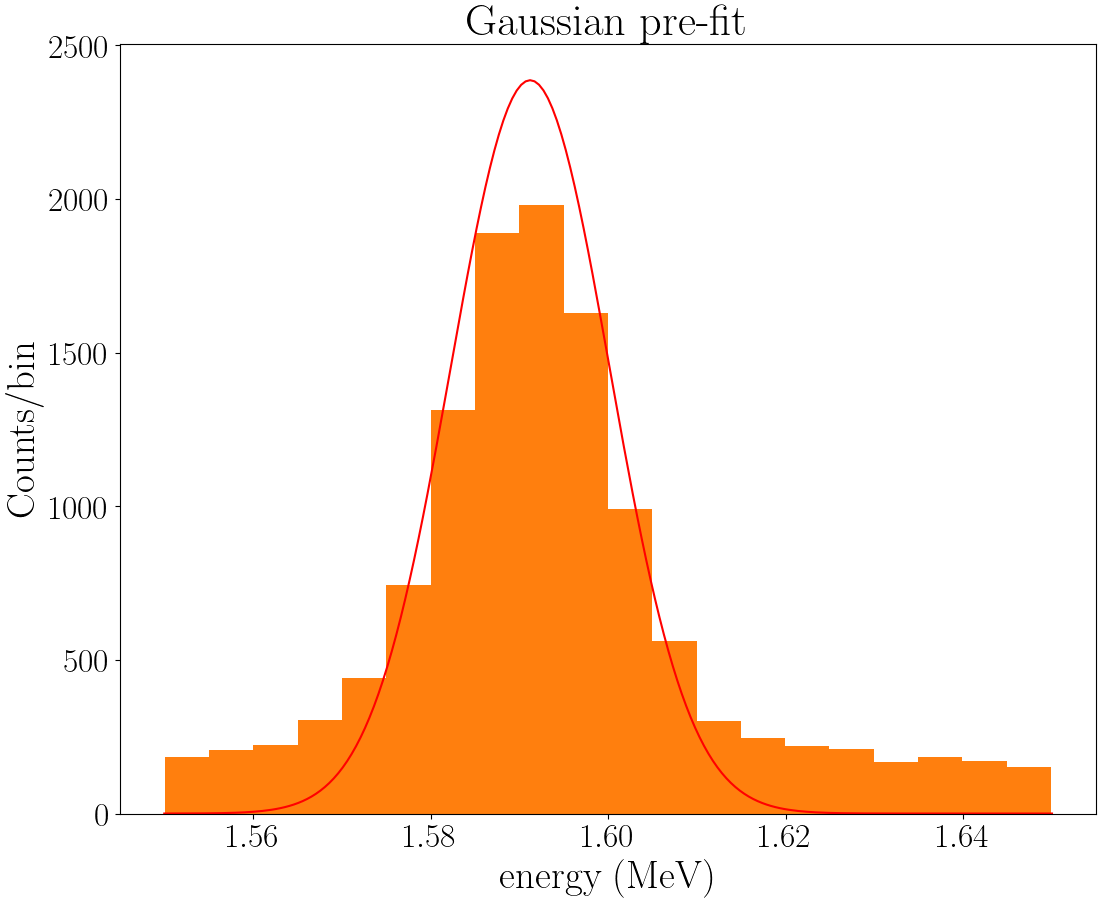

Blob cut: 0.0 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [8357.04360922]
Background events: [1908.29165335]
Total events by addition: 22562.141492989154
Total events by row counting: 22517
Total events by addition in ROI: [10265.33526258]
Total events by row counting in ROI: 10328
FOM: [1.] +/- [0.02239048]


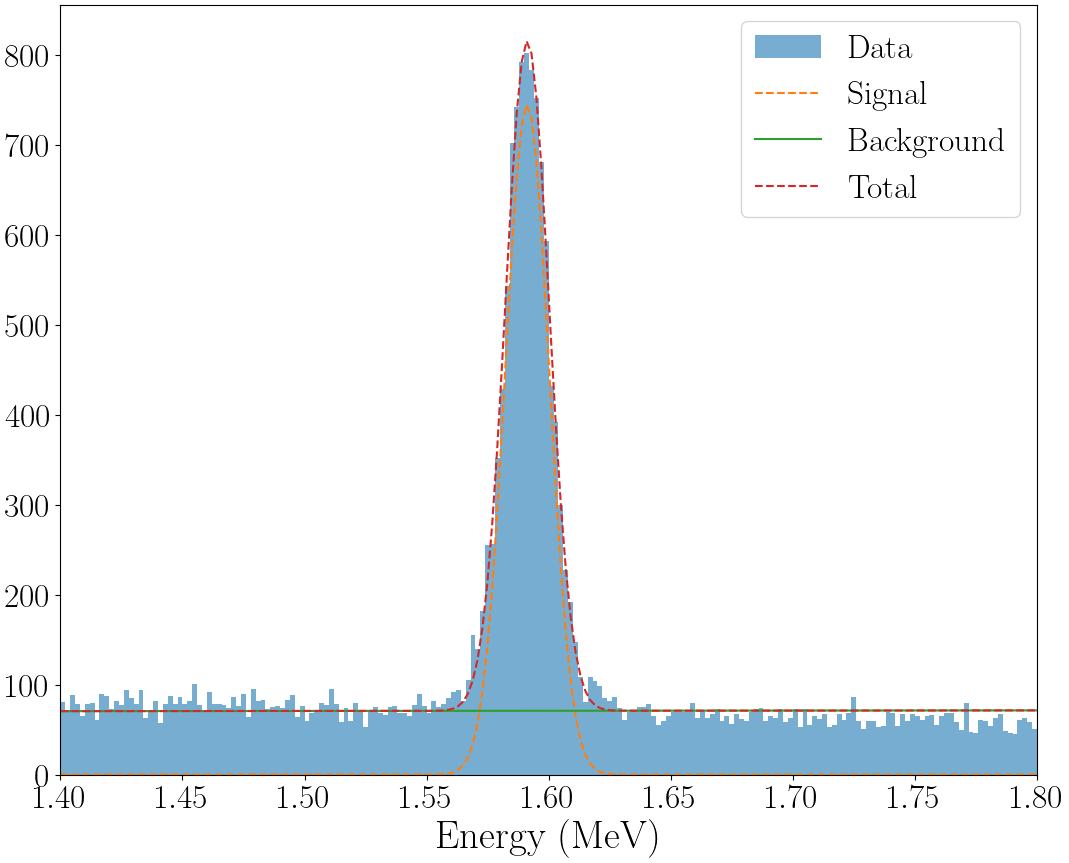

Blob cut: 0.014000000000000002 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [8357.16694542]
Background events: [1908.14049038]
Total events by addition: 22561.141715831625
Total events by row counting: 22516
Total events by addition in ROI: [10265.3074358]
Total events by row counting in ROI: 10328
FOM: [1.00005437] +/- [0.02239189]


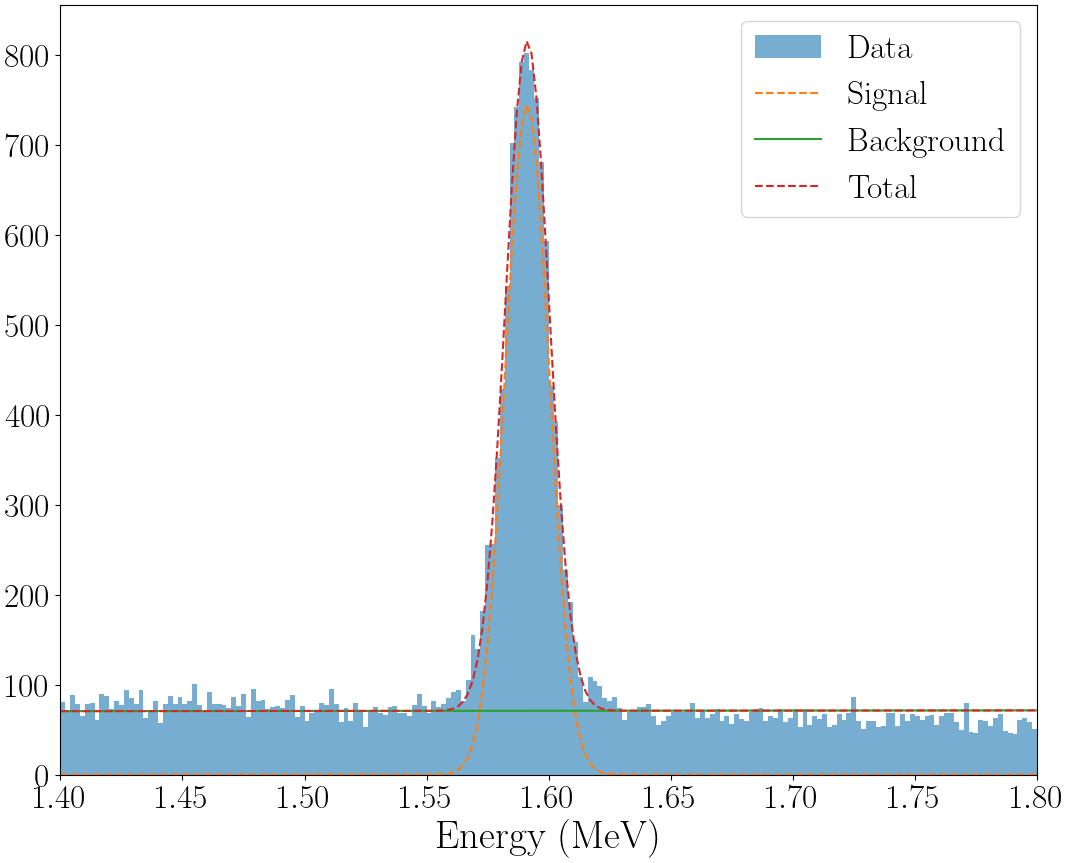

Blob cut: 0.028000000000000004 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [8357.16694542]
Background events: [1908.14049038]
Total events by addition: 22561.141715831625
Total events by row counting: 22516
Total events by addition in ROI: [10265.3074358]
Total events by row counting in ROI: 10328
FOM: [1.00005437] +/- [0.02239189]


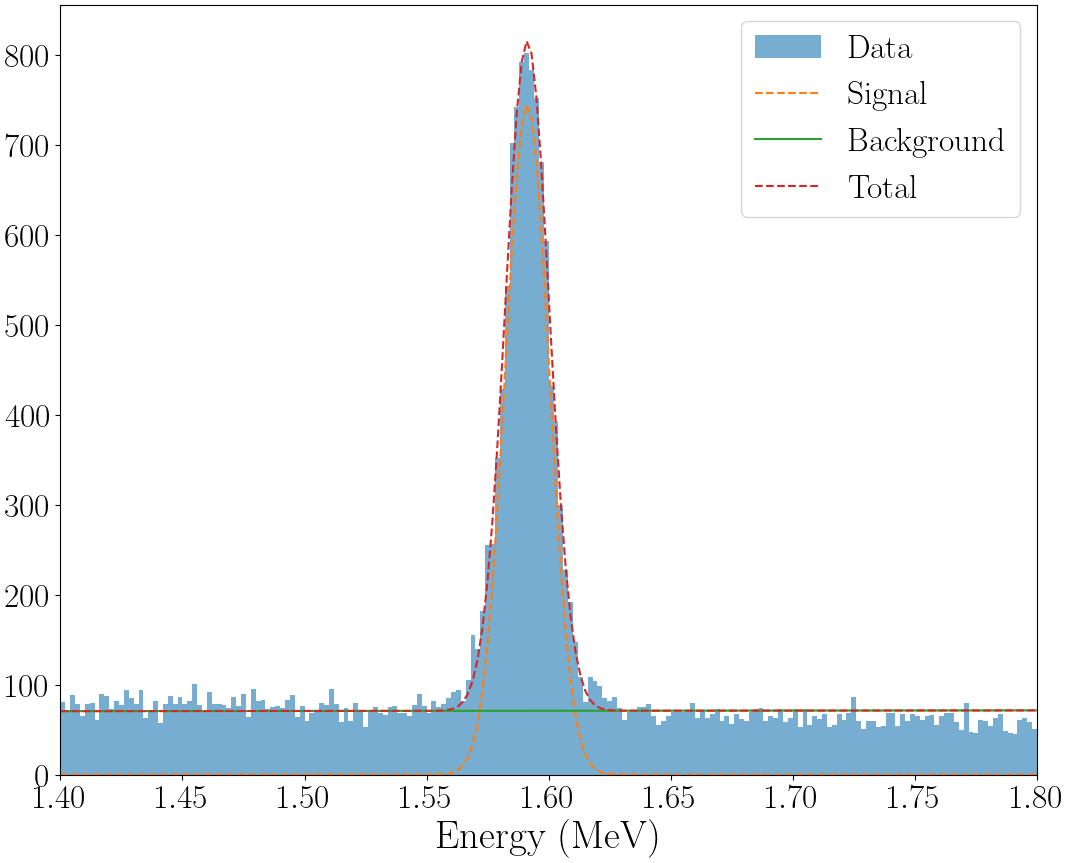

Blob cut: 0.04200000000000001 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [8354.71080728]
Background events: [1907.39584827]
Total events by addition: 22553.144728648746
Total events by row counting: 22508
Total events by addition in ROI: [10262.10665555]
Total events by row counting in ROI: 10325
FOM: [0.99995559] +/- [0.0223916]


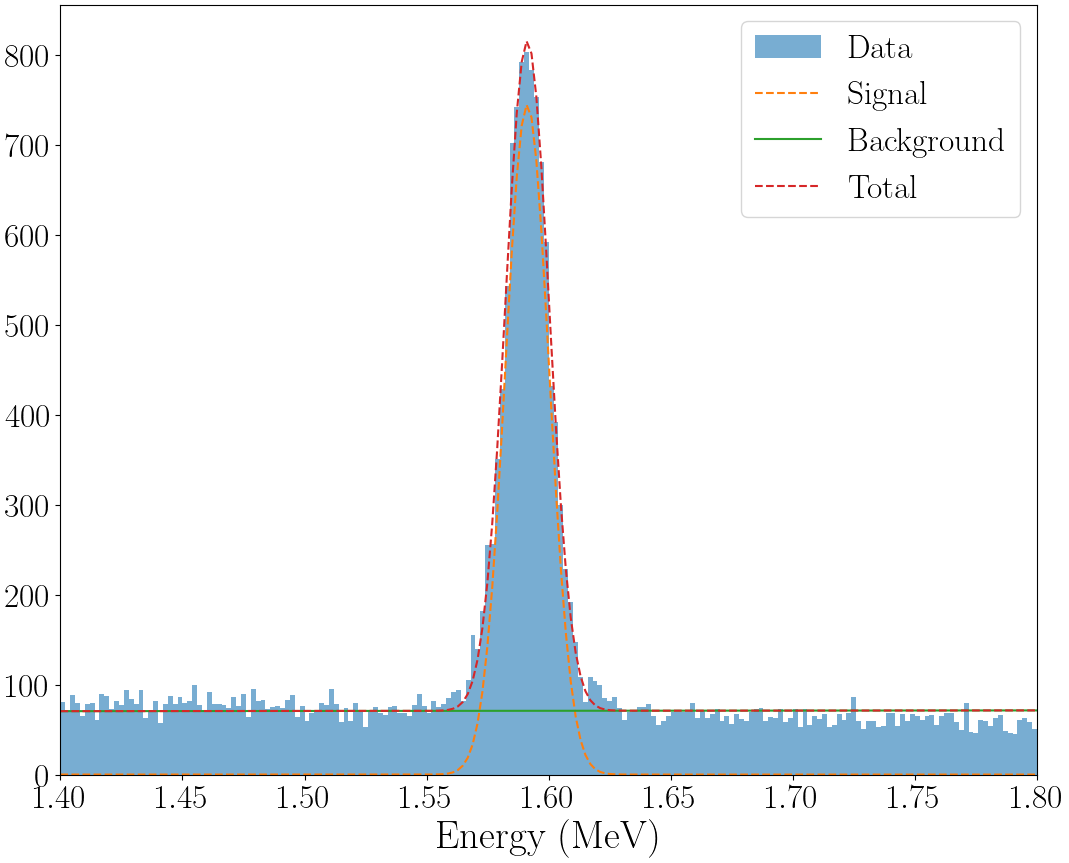

Blob cut: 0.05600000000000001 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [8350.5042504]
Background events: [1906.34891329]
Total events by addition: 22541.1459354335
Total events by row counting: 22496
Total events by addition in ROI: [10256.85316369]
Total events by row counting in ROI: 10320
FOM: [0.99972652] +/- [0.02238943]


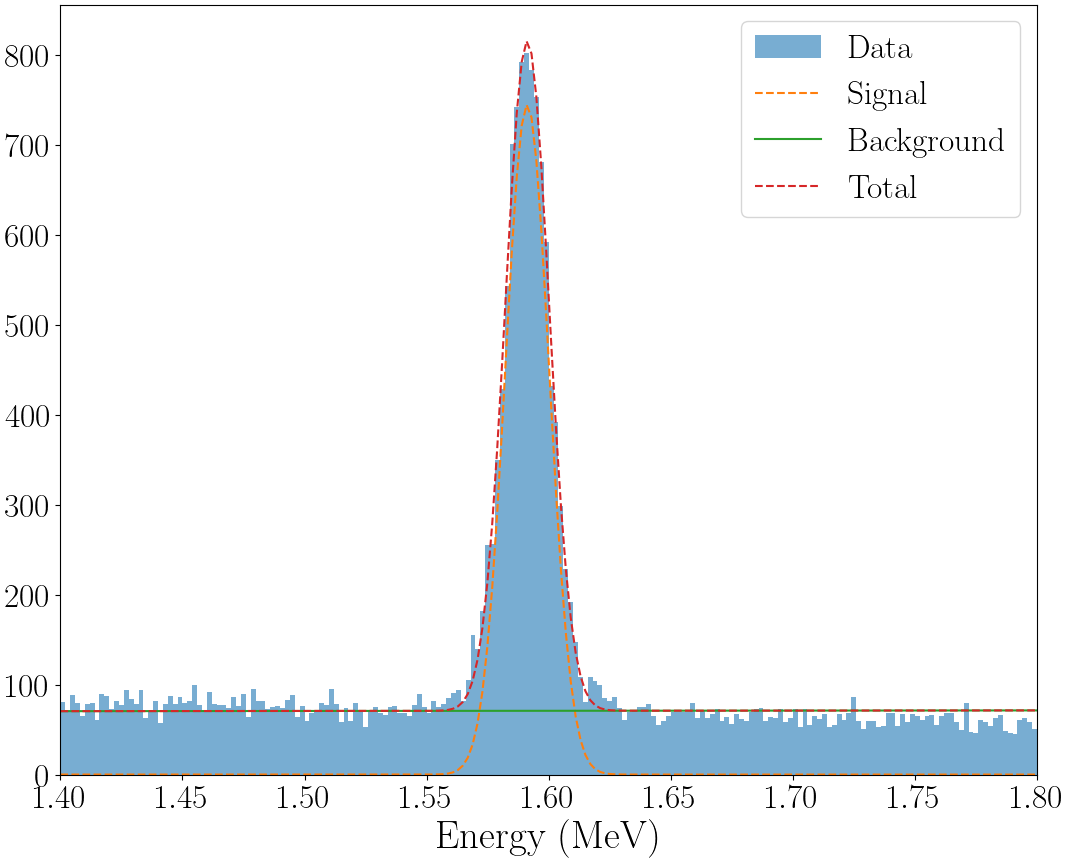

Blob cut: 0.07 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [8345.38111777]
Background events: [1903.54049231]
Total events by addition: 22515.136674263427
Total events by row counting: 22471
Total events by addition in ROI: [10248.92161008]
Total events by row counting in ROI: 10310
FOM: [0.99984993] +/- [0.02239815]


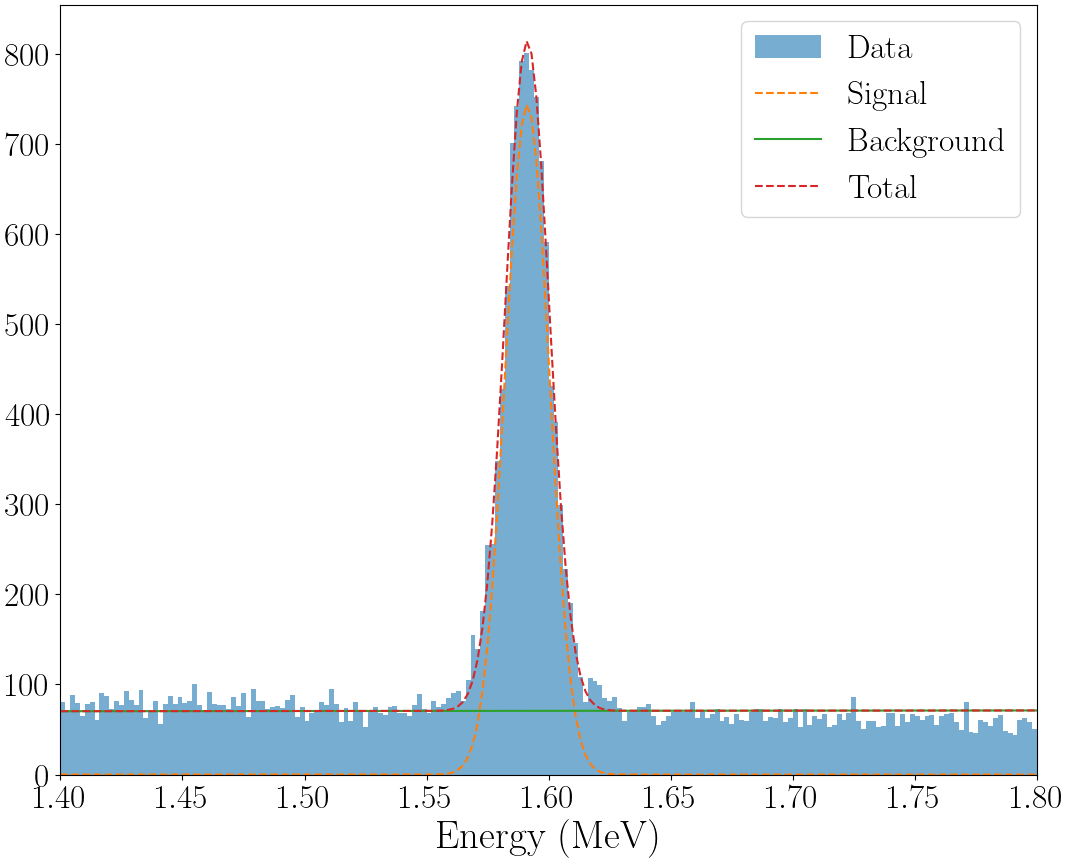

Blob cut: 0.08400000000000002 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [8339.38144973]
Background events: [1898.2036954]
Total events by addition: 22469.45754750543
Total events by row counting: 22427
Total events by addition in ROI: [10237.58514514]
Total events by row counting in ROI: 10301
FOM: [1.00053466] +/- [0.02242366]


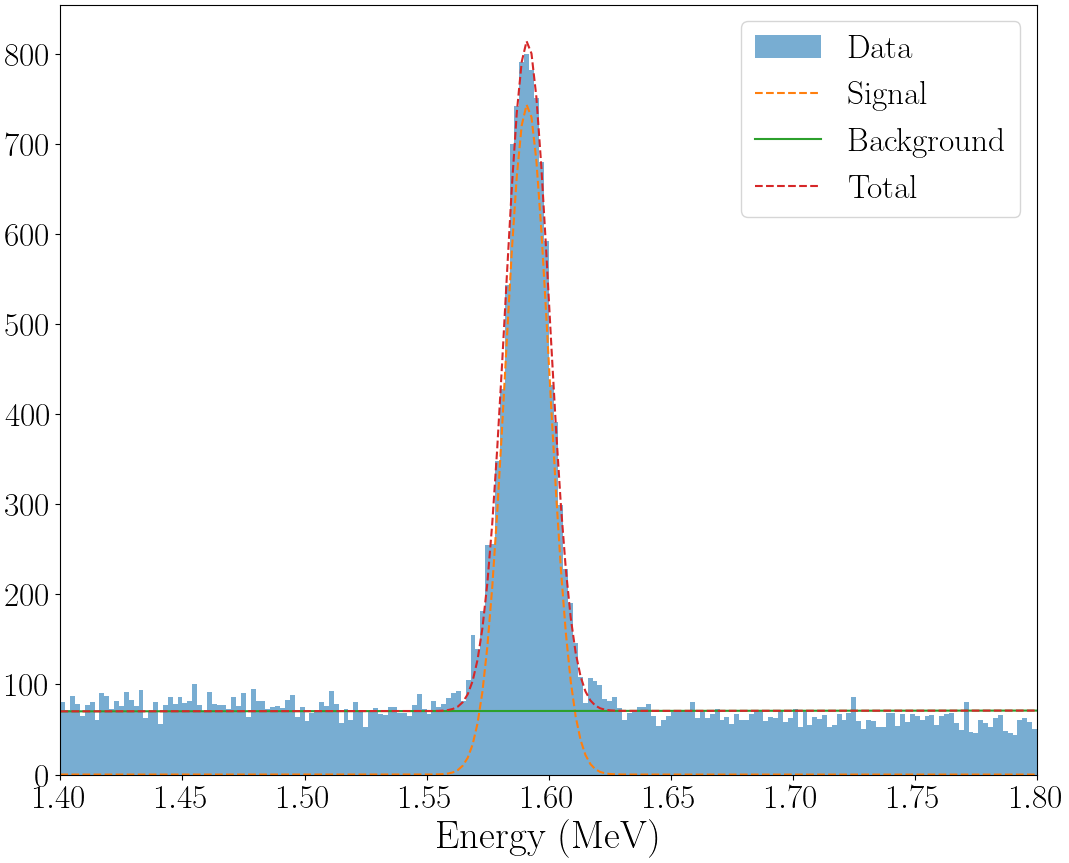

Blob cut: 0.09800000000000002 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [8332.21233048]
Background events: [1888.63432101]
Total events by addition: 22391.14917485279
Total events by row counting: 22347
Total events by addition in ROI: [10220.84665149]
Total events by row counting in ROI: 10282
FOM: [1.00220392] +/- [0.02247829]


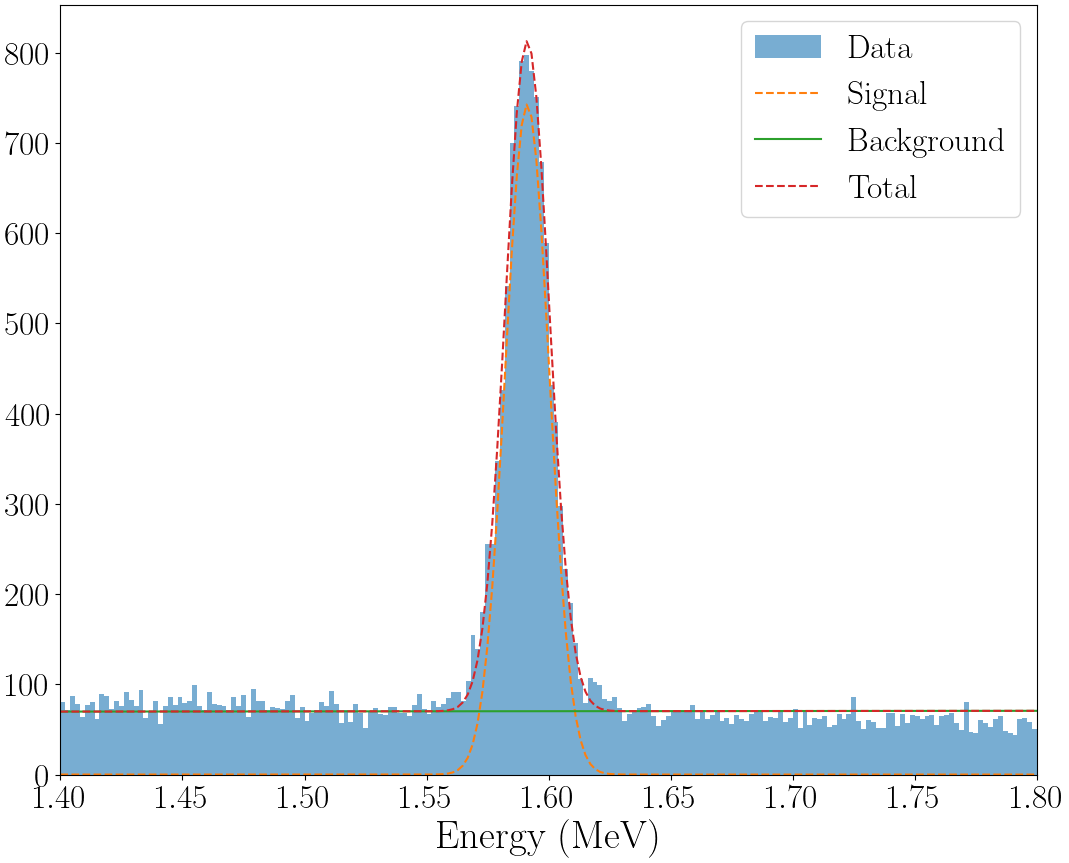

Blob cut: 0.11200000000000002 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [8325.36855511]
Background events: [1870.94347413]
Total events by addition: 22252.808026549643
Total events by row counting: 22212
Total events by addition in ROI: [10196.31202924]
Total events by row counting in ROI: 10259
FOM: [1.00610392] +/- [0.02259603]


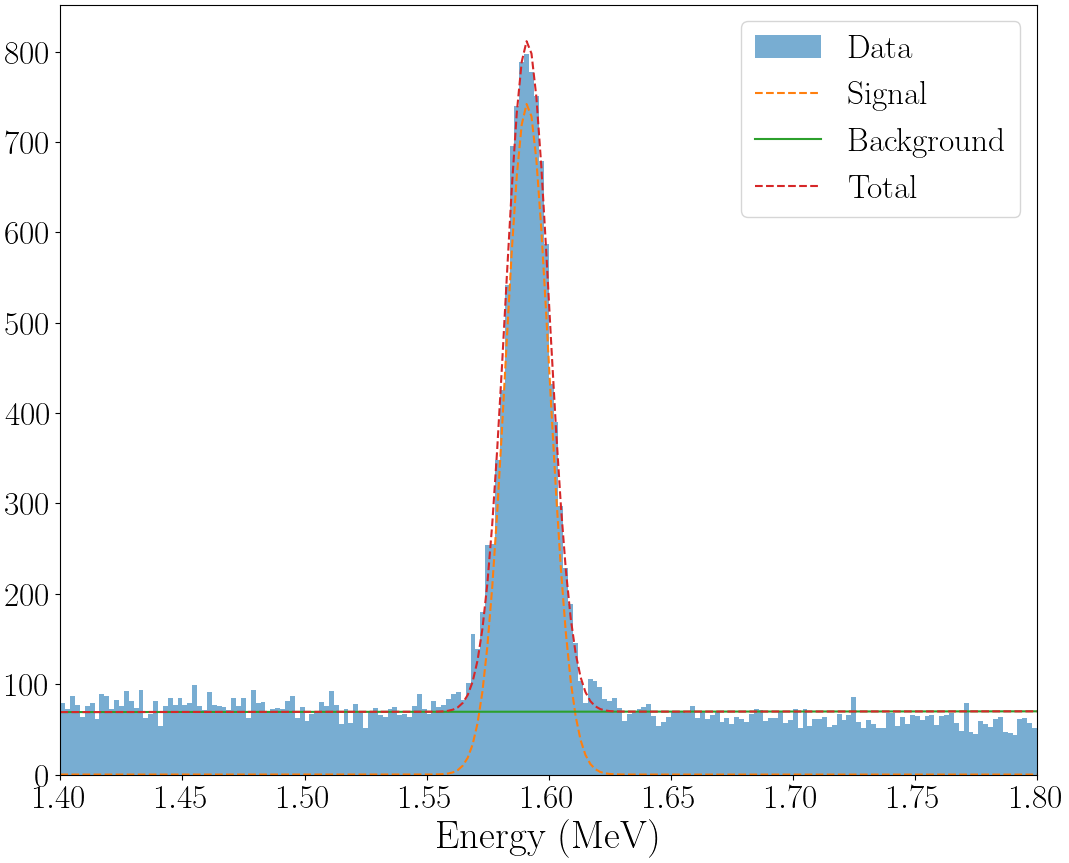

Blob cut: 0.12600000000000003 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [8322.58219765]
Background events: [1836.92053398]
Total events by addition: 21997.154727009627
Total events by row counting: 21955
Total events by addition in ROI: [10159.50273163]
Total events by row counting in ROI: 10219
FOM: [1.01503873] +/- [0.02285346]


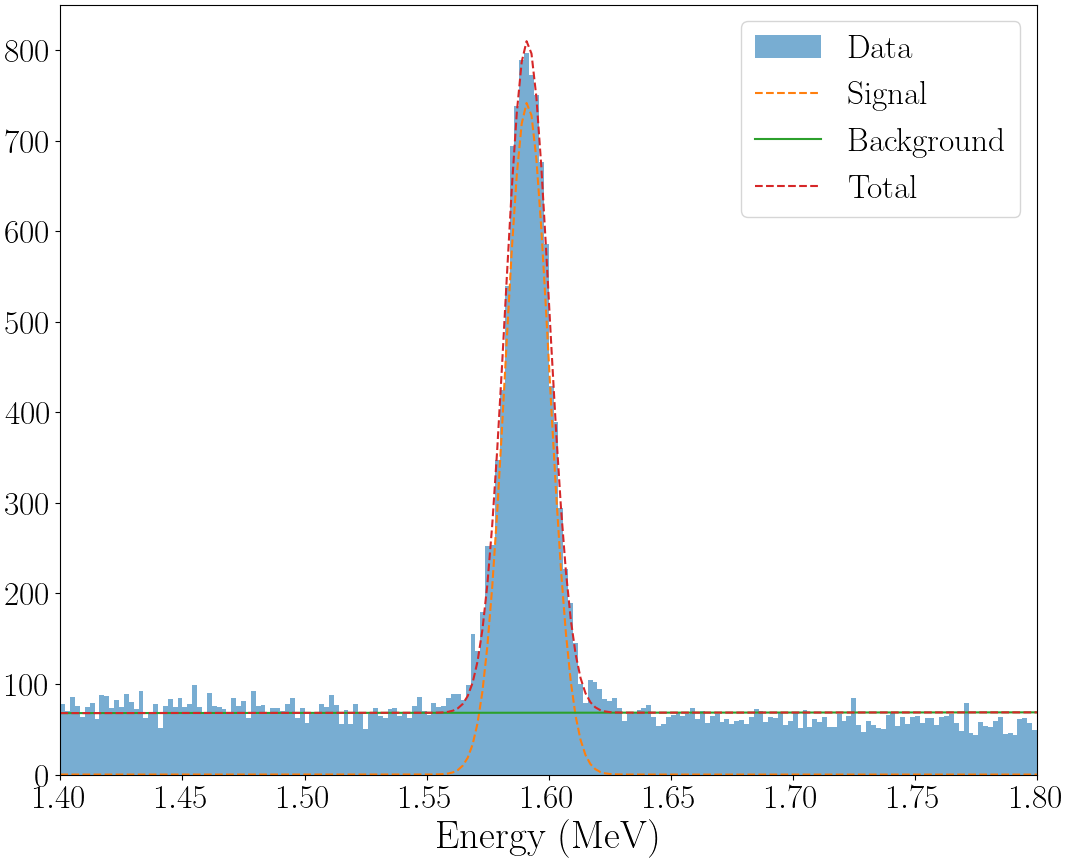

Blob cut: 0.14 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [8307.13240446]
Background events: [1776.88623249]
Total events by addition: 21535.48657889349
Total events by row counting: 21493
Total events by addition in ROI: [10084.01863695]
Total events by row counting in ROI: 10147
FOM: [1.03012761] +/- [0.02330323]


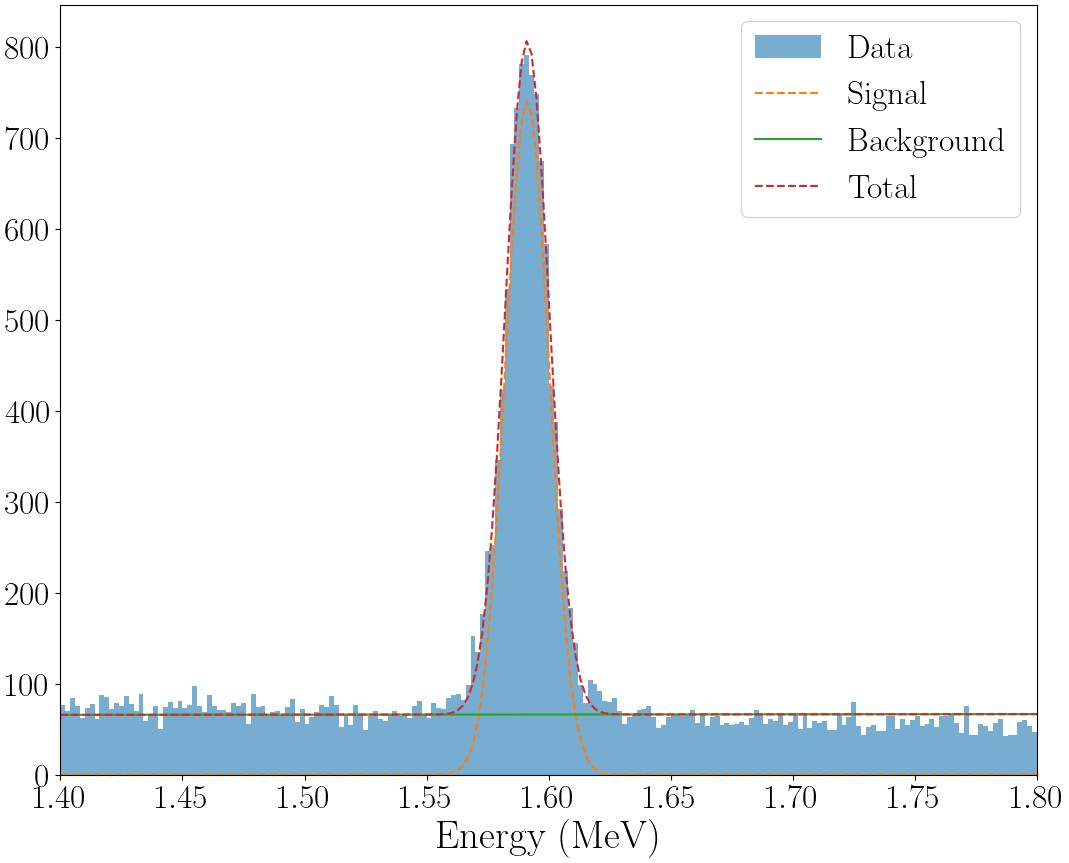

Blob cut: 0.15400000000000003 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [8287.60374483]
Background events: [1679.20708926]
Total events by addition: 20789.9510539599
Total events by row counting: 20753
Total events by addition in ROI: [9966.81083408]
Total events by row counting in ROI: 10030
FOM: [1.0571742] +/- [0.02411212]


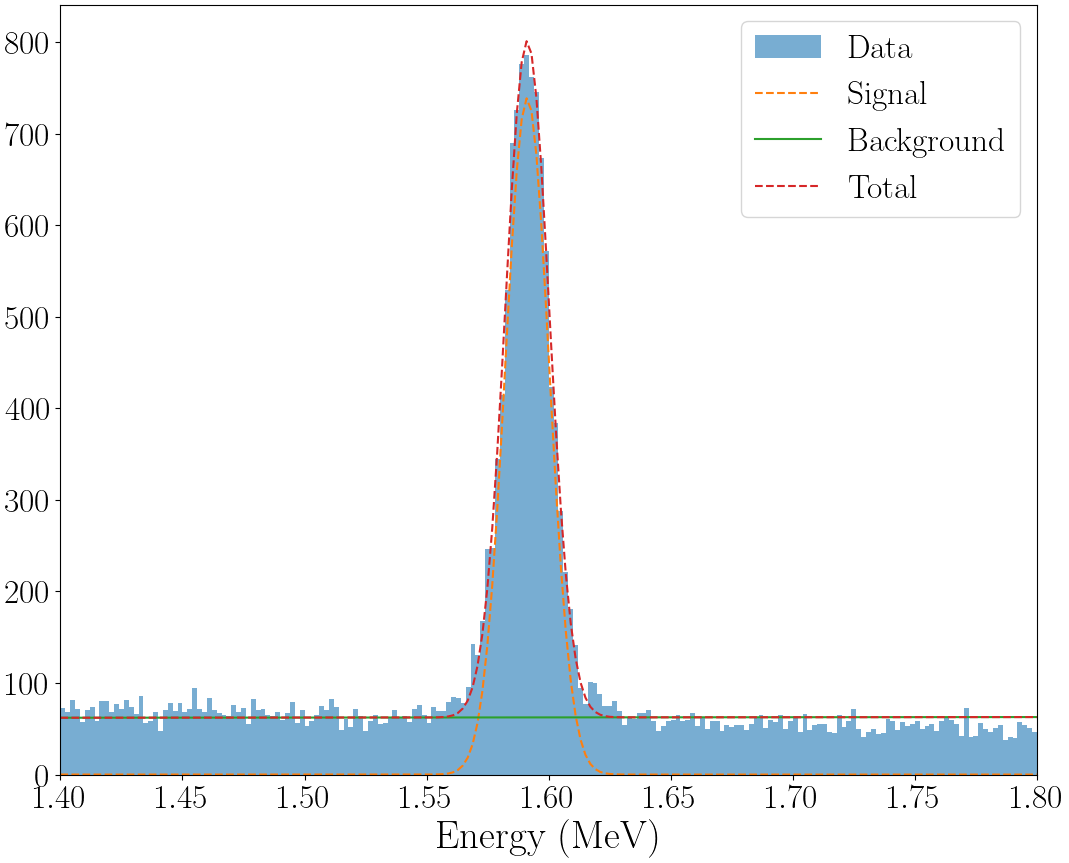

Blob cut: 0.16800000000000004 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [8276.05724441]
Background events: [1547.04771165]
Total events by addition: 19796.16127482774
Total events by row counting: 19766
Total events by addition in ROI: [9823.10495606]
Total events by row counting in ROI: 9878
FOM: [1.09986996] +/- [0.02539474]


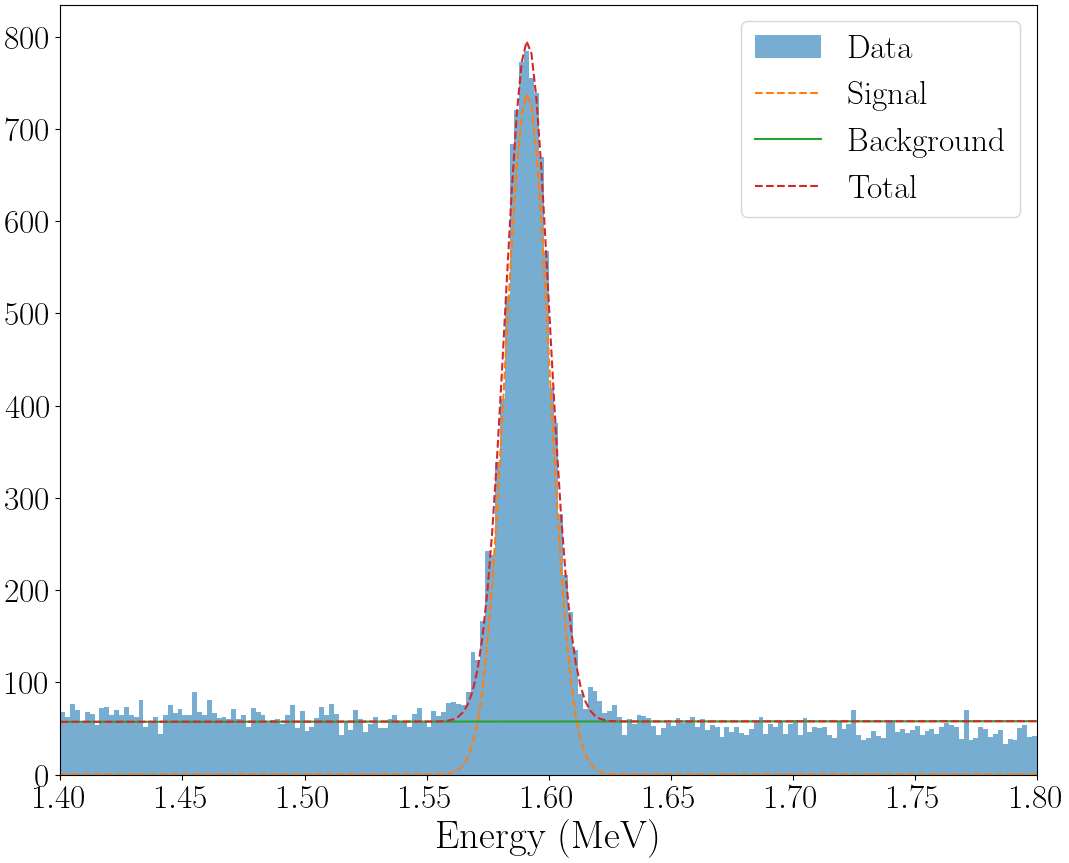

Blob cut: 0.18200000000000002 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [8231.63461816]
Background events: [1394.40241638]
Total events by addition: 18617.15448399893
Total events by row counting: 18592
Total events by addition in ROI: [9626.03703454]
Total events by row counting in ROI: 9687
FOM: [1.15228983] +/- [0.02705889]


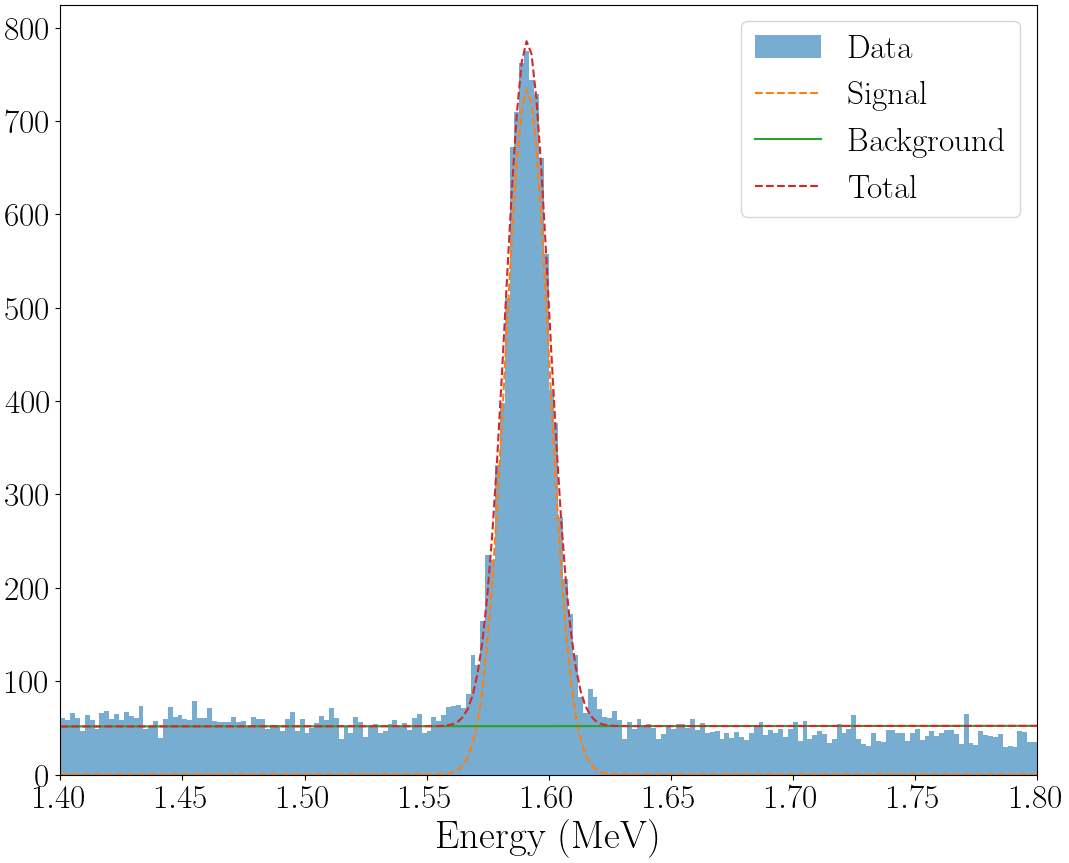

Blob cut: 0.19600000000000004 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [8179.19046634]
Background events: [1236.5008722]
Total events by addition: 17391.039870283323
Total events by row counting: 17368
Total events by addition in ROI: [9415.69133854]
Total events by row counting in ROI: 9470
FOM: [1.21585788] +/- [0.02915808]


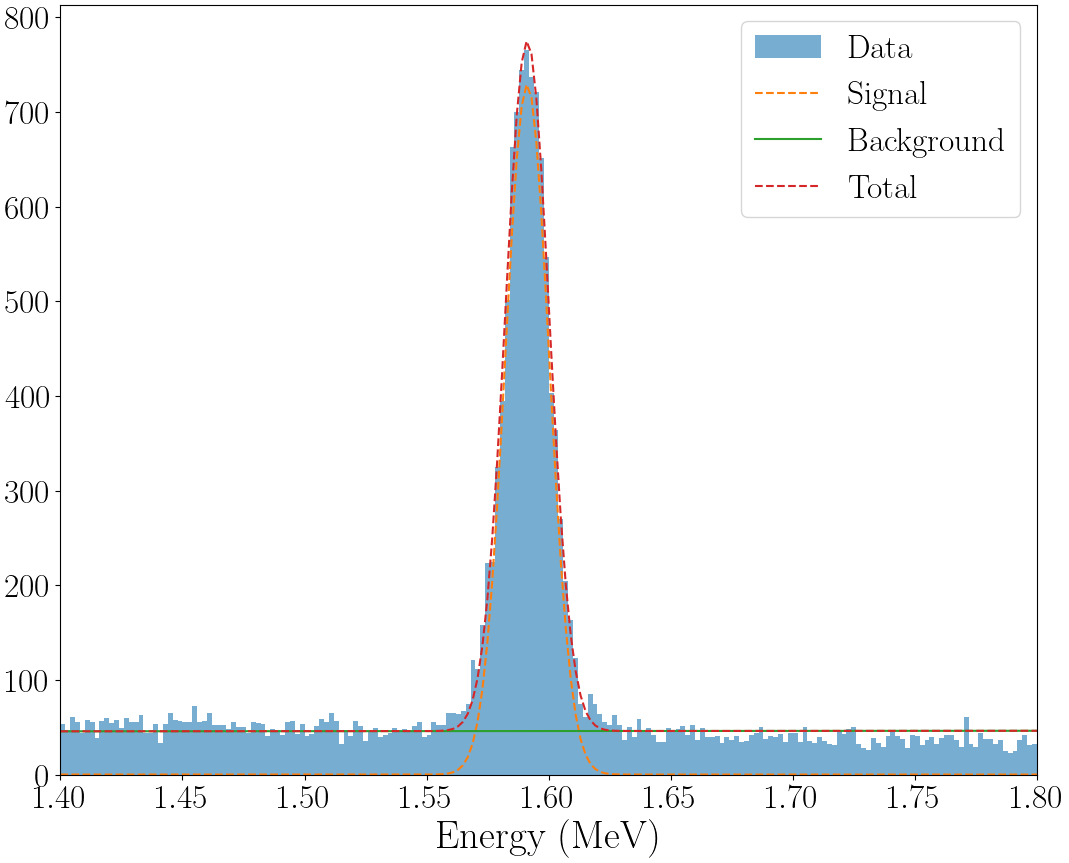

Blob cut: 0.21000000000000002 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [8129.25240795]
Background events: [1095.20848836]
Total events by addition: 16290.877857178639
Total events by row counting: 16272
Total events by addition in ROI: [9224.46089631]
Total events by row counting in ROI: 9285
FOM: [1.28402037] +/- [0.03150292]


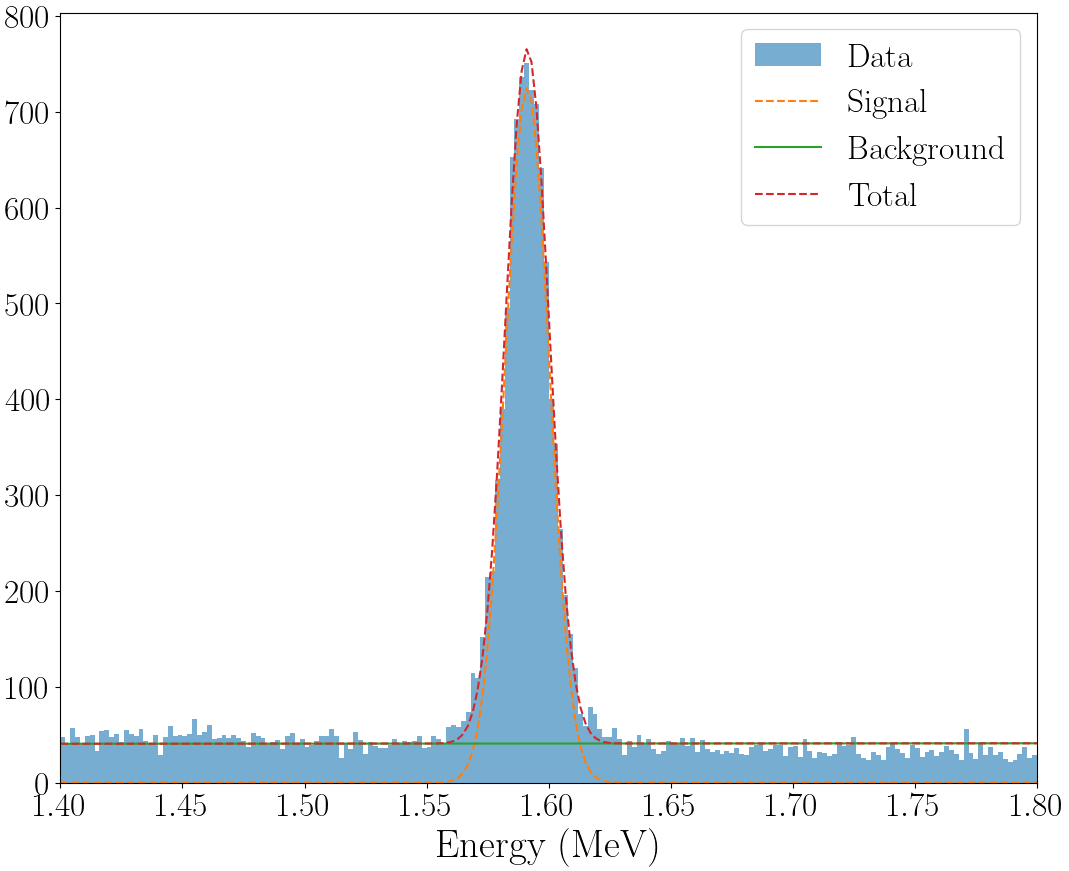

Blob cut: 0.22400000000000003 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [8046.87419873]
Background events: [965.06927883]
Total events by addition: 15241.07856343672
Total events by row counting: 15225
Total events by addition in ROI: [9011.94347756]
Total events by row counting in ROI: 9060
FOM: [1.35399691] +/- [0.03409243]


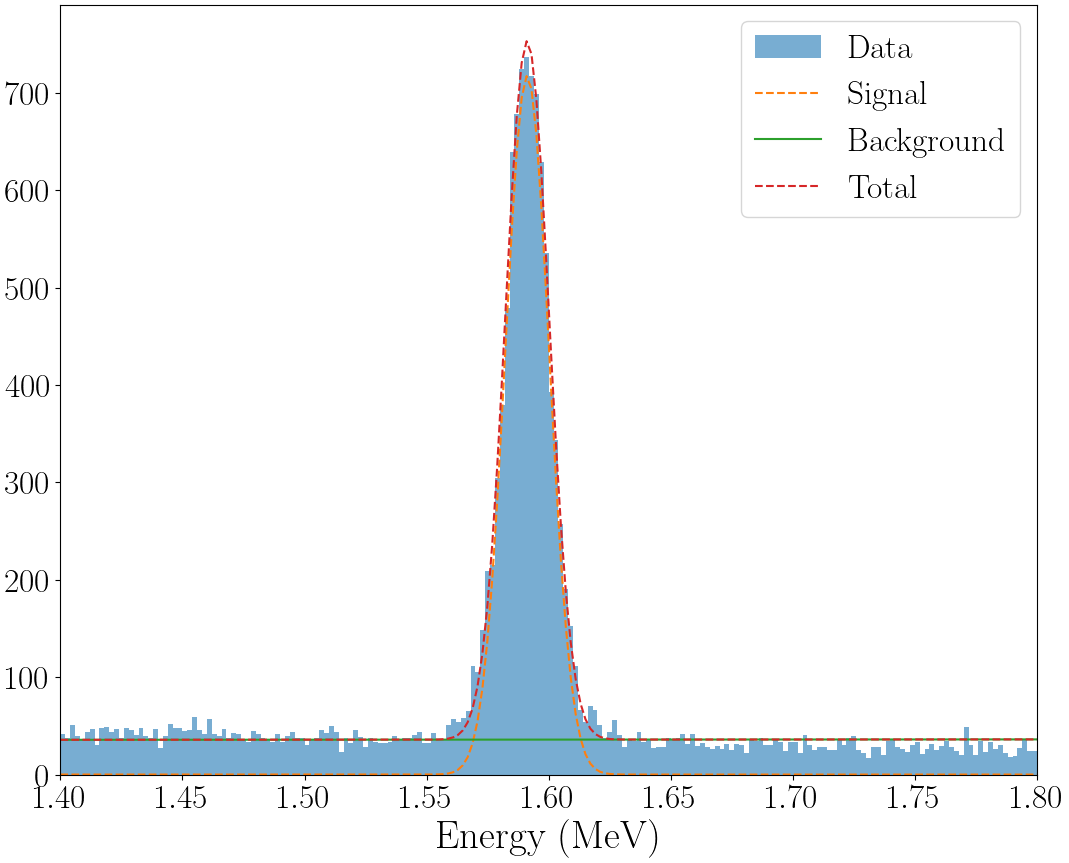

Blob cut: 0.23800000000000004 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [7995.63388715]
Background events: [862.71669414]
Total events by addition: 14429.01239817918
Total events by row counting: 14414
Total events by addition in ROI: [8858.35058128]
Total events by row counting in ROI: 8901
FOM: [1.42294628] +/- [0.03670863]


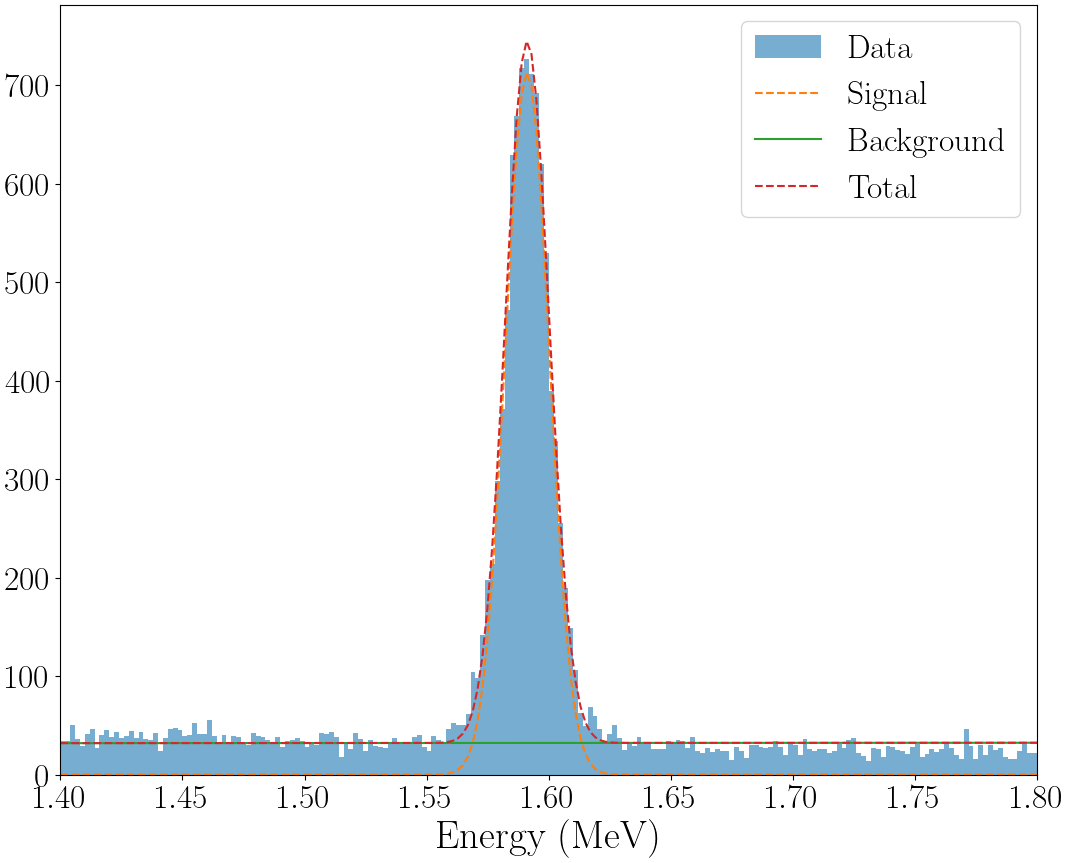

Blob cut: 0.25200000000000006 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [7922.04142663]
Background events: [772.67292025]
Total events by addition: 13686.012984782716
Total events by row counting: 13675
Total events by addition in ROI: [8694.71434688]
Total events by row counting in ROI: 8733
FOM: [1.48973482] +/- [0.03942732]


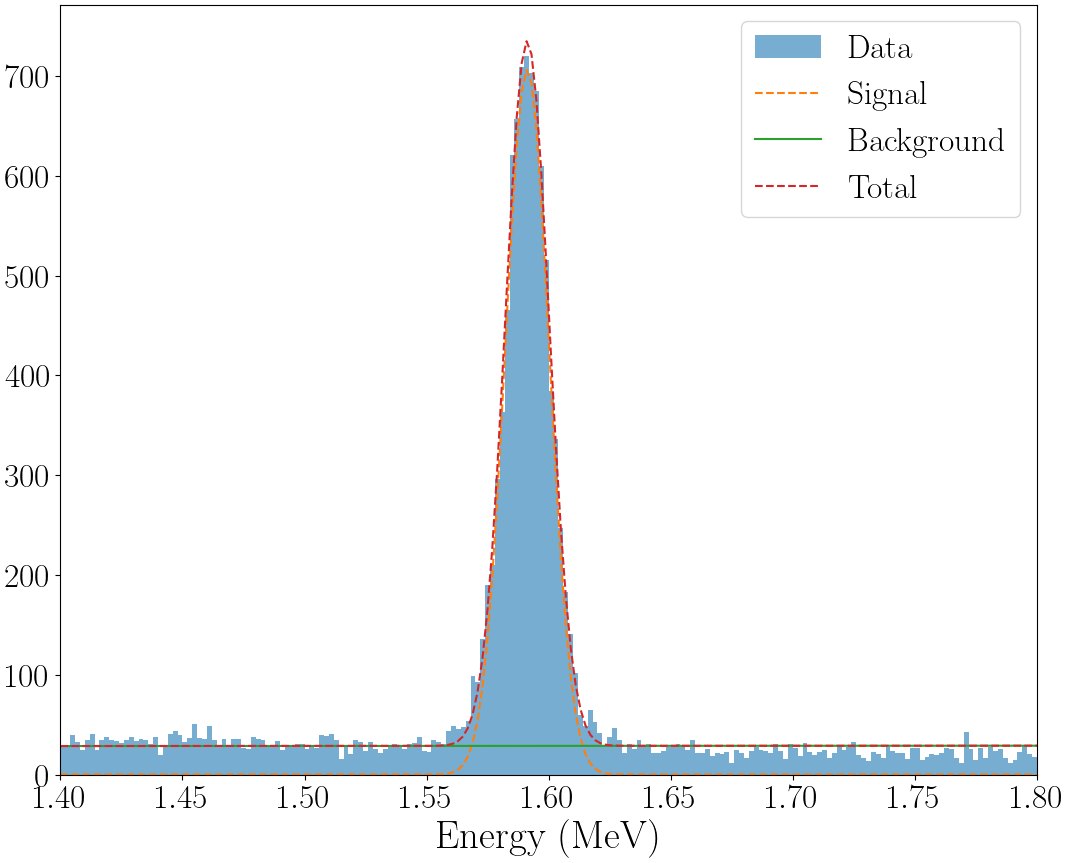

Blob cut: 0.266 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [7830.32063739]
Background events: [691.53466101]
Total events by addition: 12991.022189877824
Total events by row counting: 12981
Total events by addition in ROI: [8521.85529841]
Total events by row counting in ROI: 8556
FOM: [1.55647546] +/- [0.04233757]


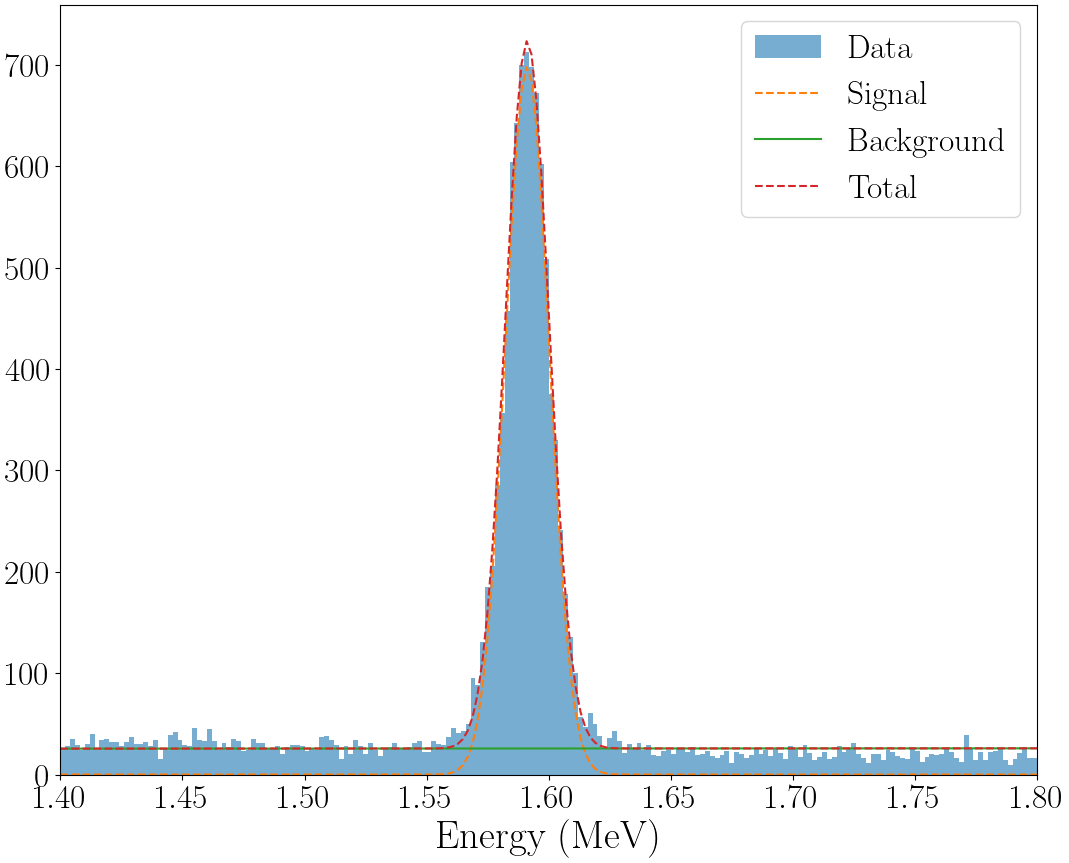

Blob cut: 0.28 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [7736.62896381]
Background events: [614.5976782]
Total events by addition: 12325.279173702944
Total events by row counting: 12318
Total events by addition in ROI: [8351.22664201]
Total events by row counting in ROI: 8378
FOM: [1.63127064] +/- [0.04575393]


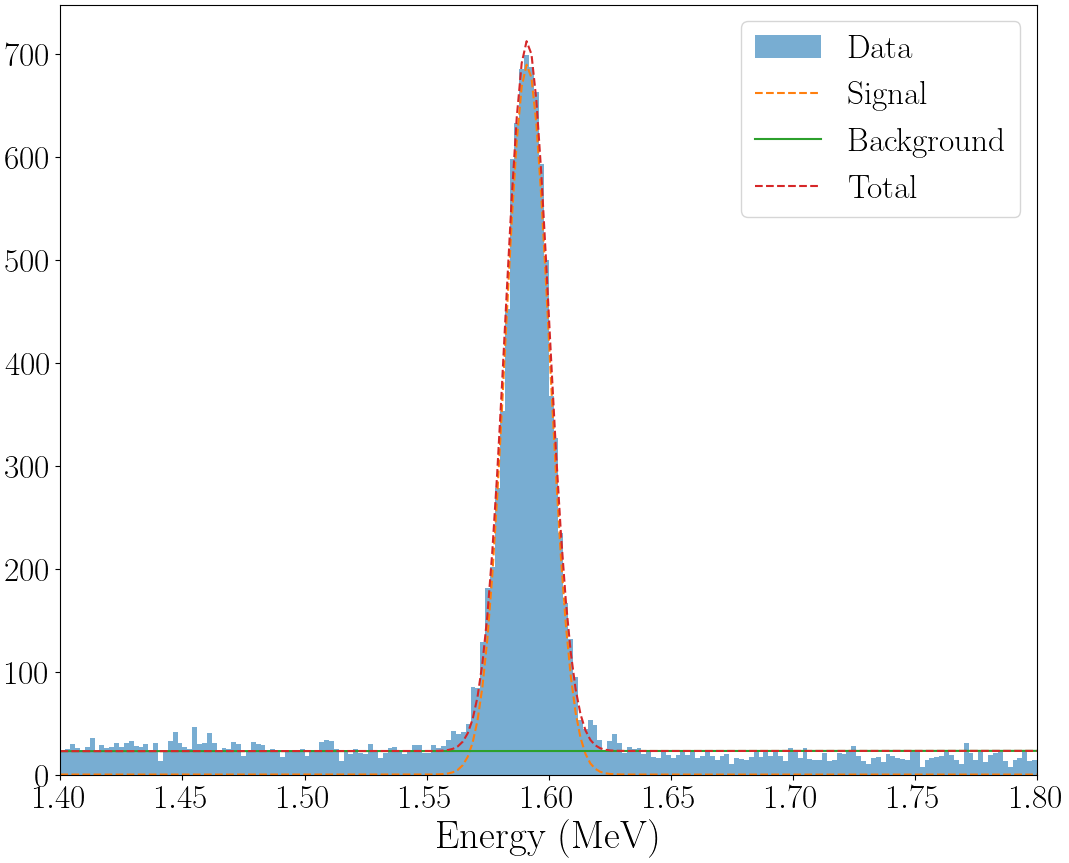

Blob cut: 0.29400000000000004 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [7602.11168424]
Background events: [557.74640513]
Total events by addition: 11767.877563242044
Total events by row counting: 11761
Total events by addition in ROI: [8159.85808938]
Total events by row counting in ROI: 8183
FOM: [1.68261812] +/- [0.04848865]


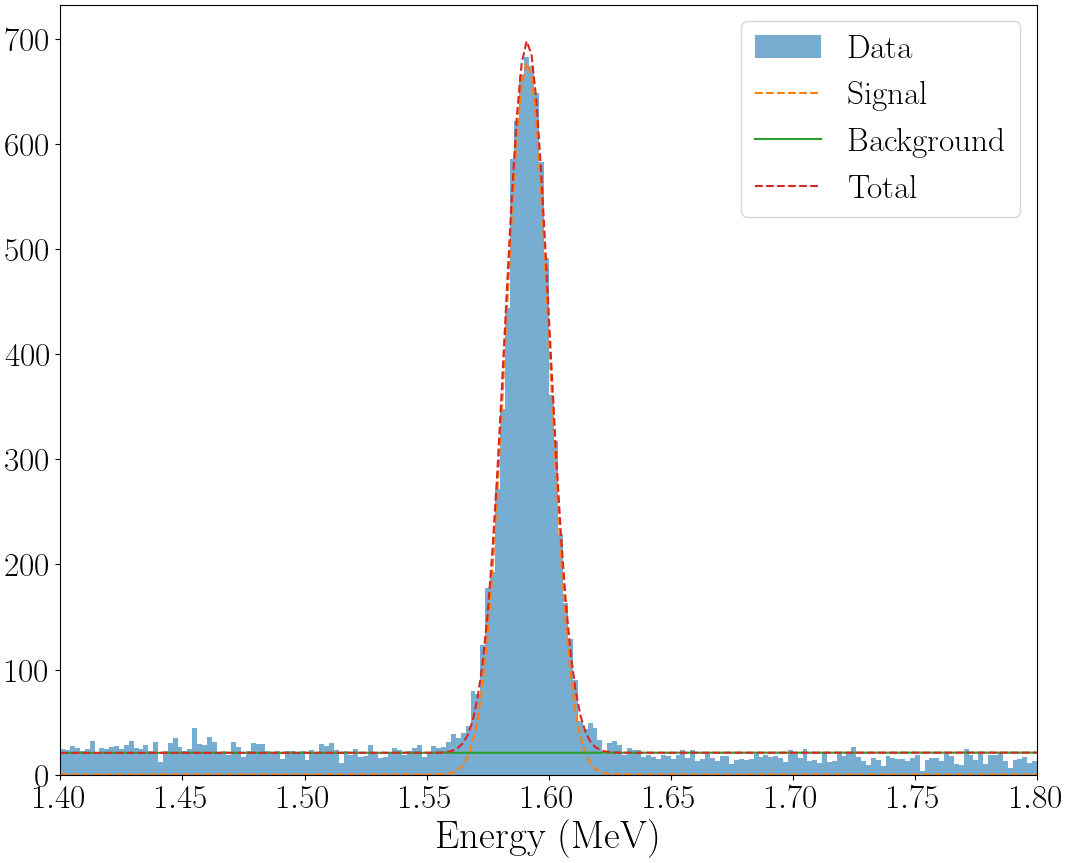

Blob cut: 0.30800000000000005 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [7471.39760735]
Background events: [504.84872294]
Total events by addition: 11243.672643998436
Total events by row counting: 11235
Total events by addition in ROI: [7976.24633029]
Total events by row counting in ROI: 7997
FOM: [1.7381647] +/- [0.05155375]


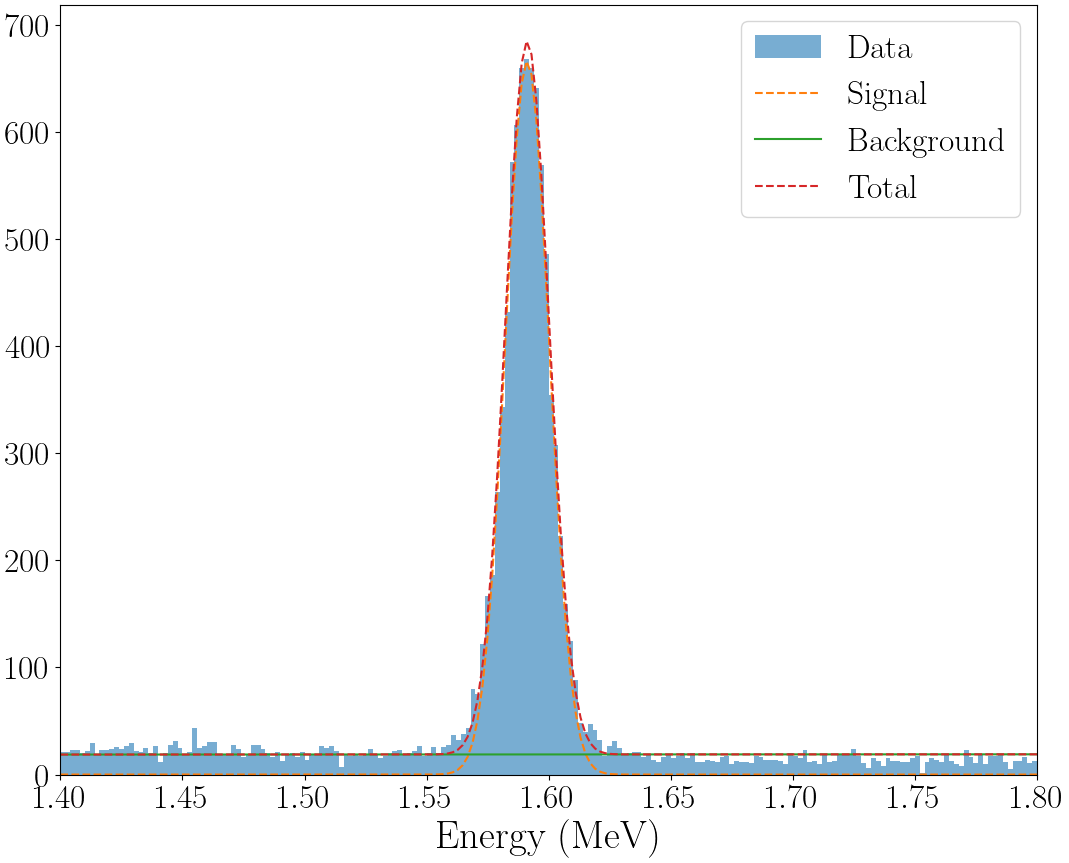

Blob cut: 0.32200000000000006 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [7319.21924299]
Background events: [455.11169759]
Total events by addition: 10721.435417226709
Total events by row counting: 10717
Total events by addition in ROI: [7774.33094058]
Total events by row counting in ROI: 7795
FOM: [1.79339298] +/- [0.05488512]


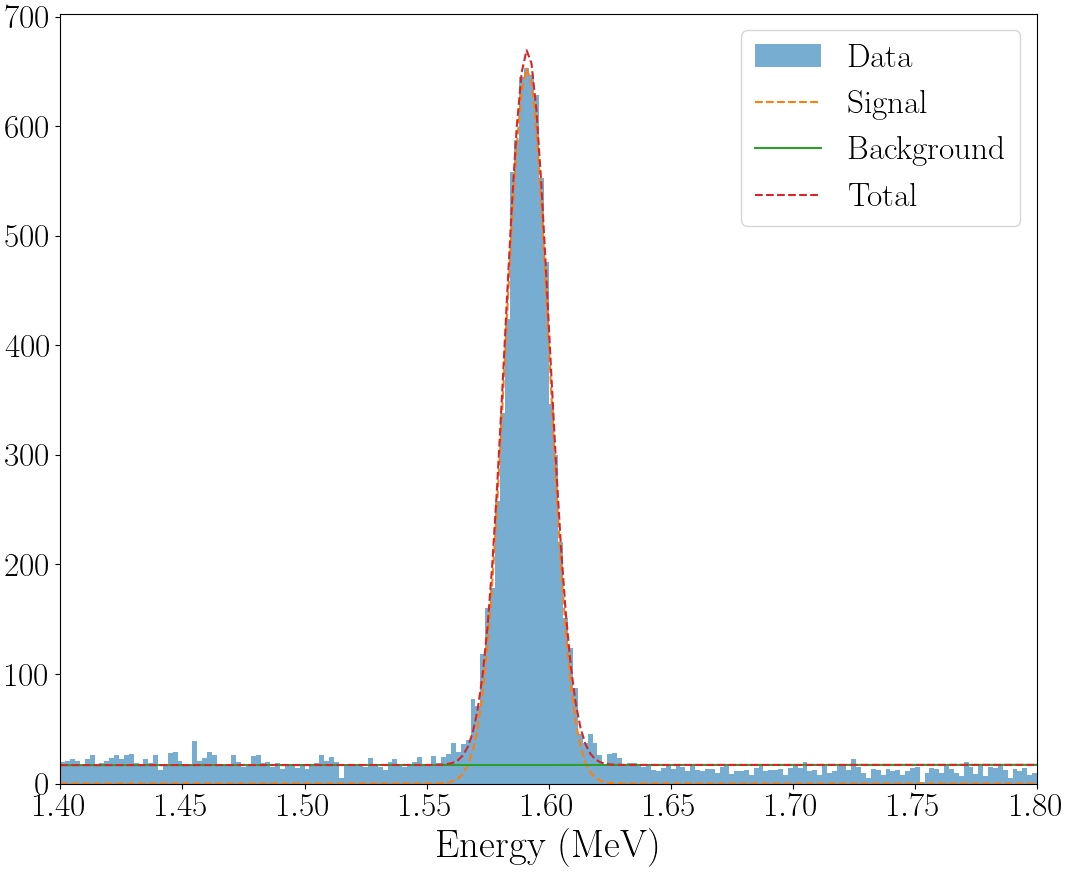

Blob cut: 0.3360000000000001 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [7152.7720937]
Background events: [412.52632305]
Total events by addition: 10238.042038051952
Total events by row counting: 10231
Total events by addition in ROI: [7565.29841675]
Total events by row counting in ROI: 7582
FOM: [1.84084941] +/- [0.05811065]


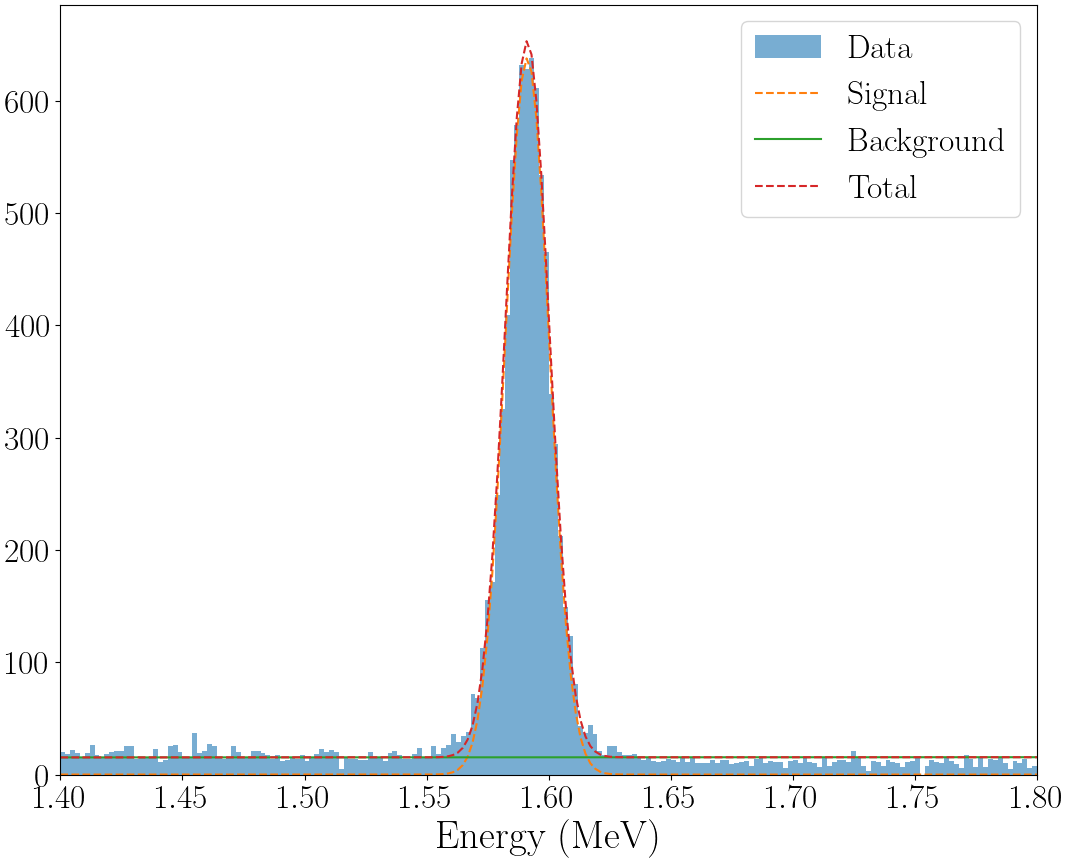

Blob cut: 0.35000000000000003 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [6947.61270915]
Background events: [377.22948265]
Total events by addition: 9770.000205807592
Total events by row counting: 9763
Total events by addition in ROI: [7324.8421918]
Total events by row counting in ROI: 7336
FOM: [1.86983159] +/- [0.06080052]


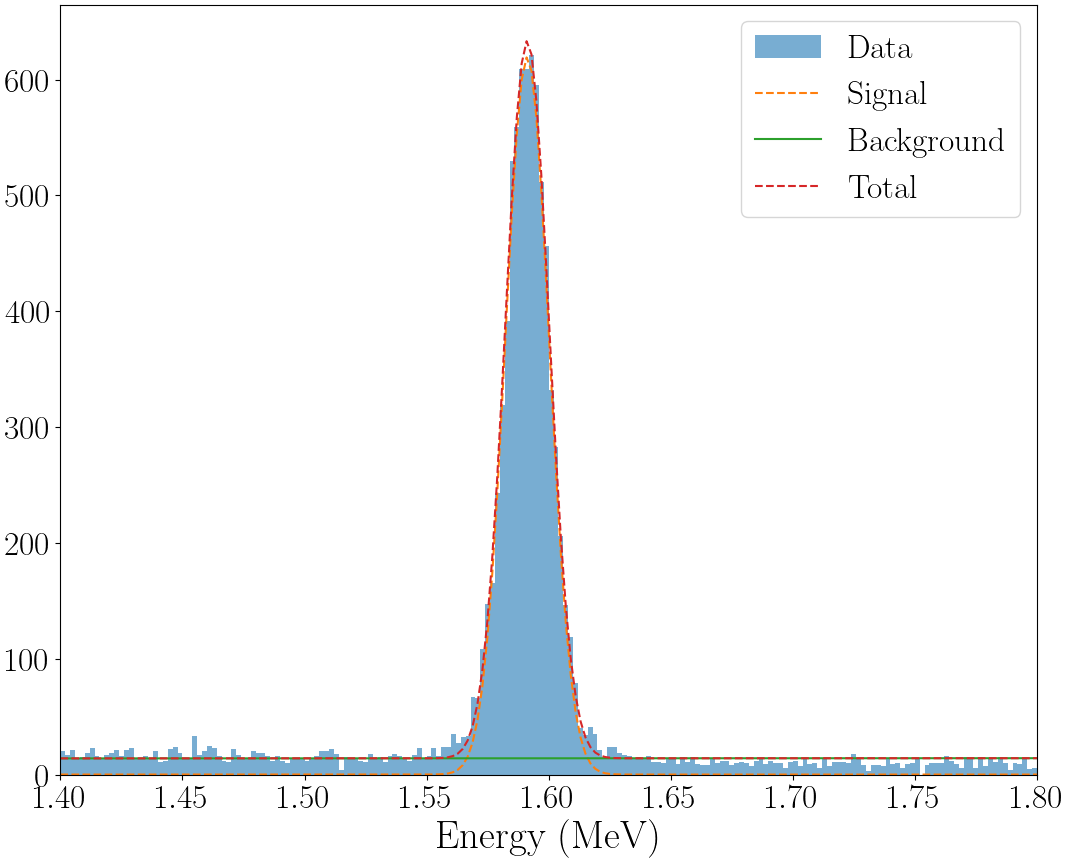

Blob cut: 0.36400000000000005 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [6668.51010844]
Background events: [340.30157436]
Total events by addition: 9215.692845280319
Total events by row counting: 9209
Total events by addition in ROI: [7008.8116828]
Total events by row counting in ROI: 7022
FOM: [1.88958547] +/- [0.06366719]


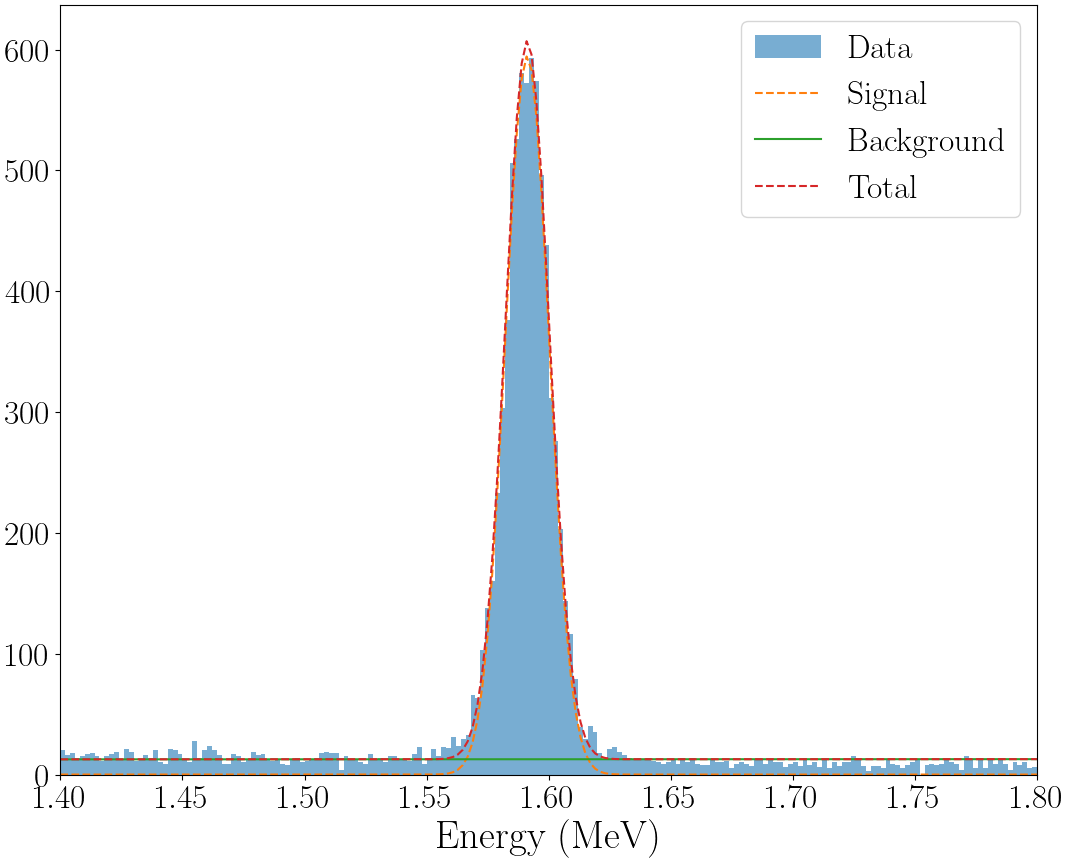

Blob cut: 0.37800000000000006 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [6361.18546369]
Background events: [305.62146953]
Total events by addition: 8649.792776001745
Total events by row counting: 8645
Total events by addition in ROI: [6666.80693323]
Total events by row counting in ROI: 6677
FOM: [1.90202331] +/- [0.0665946]


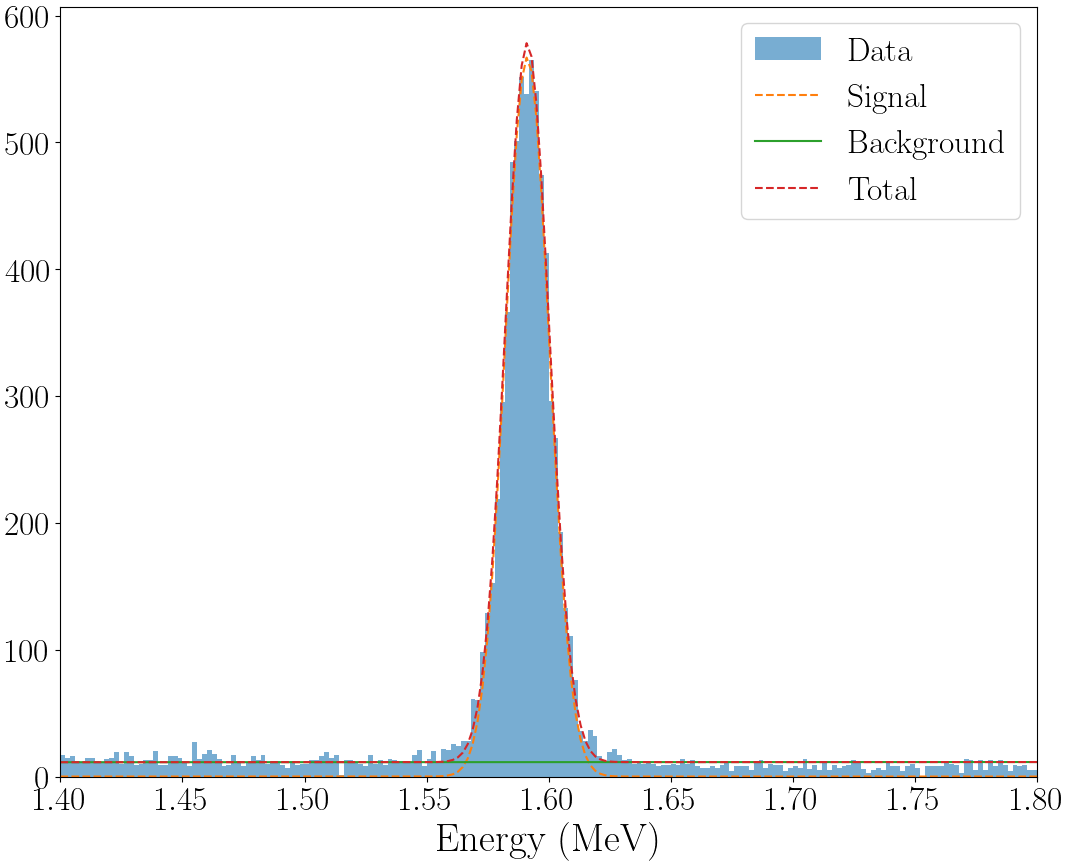

Blob cut: 0.39200000000000007 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [6012.66576477]
Background events: [276.06421487]
Total events by addition: 8080.659292356833
Total events by row counting: 8077
Total events by addition in ROI: [6288.72997964]
Total events by row counting in ROI: 6301
FOM: [1.89161048] +/- [0.06879246]


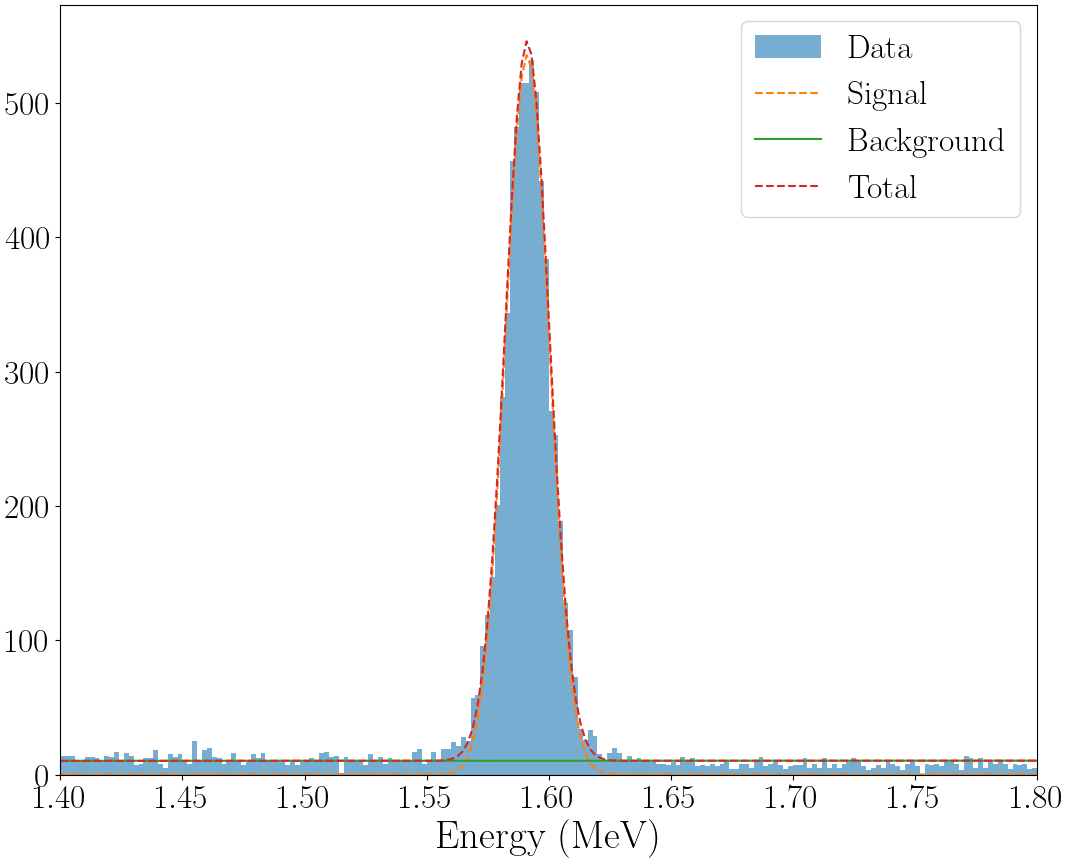

Blob cut: 0.4060000000000001 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [5574.87385996]
Background events: [241.0499847]
Total events by addition: 7381.455546029848
Total events by row counting: 7378
Total events by addition in ROI: [5815.92384466]
Total events by row counting in ROI: 5830
FOM: [1.87694349] +/- [0.07189385]


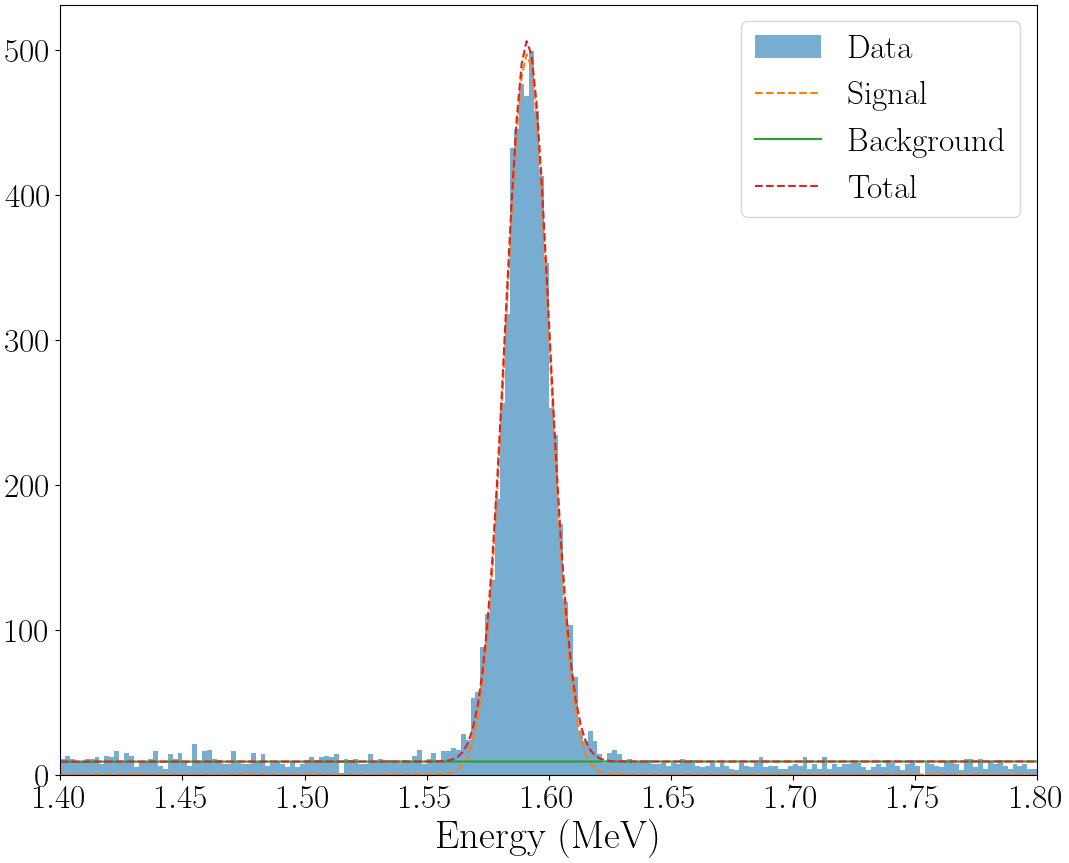

Blob cut: 0.42000000000000004 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [5104.81120568]
Background events: [209.26337311]
Total events by addition: 6673.881437353407
Total events by row counting: 6671
Total events by addition in ROI: [5314.07457879]
Total events by row counting in ROI: 5326
FOM: [1.84460245] +/- [0.07472865]


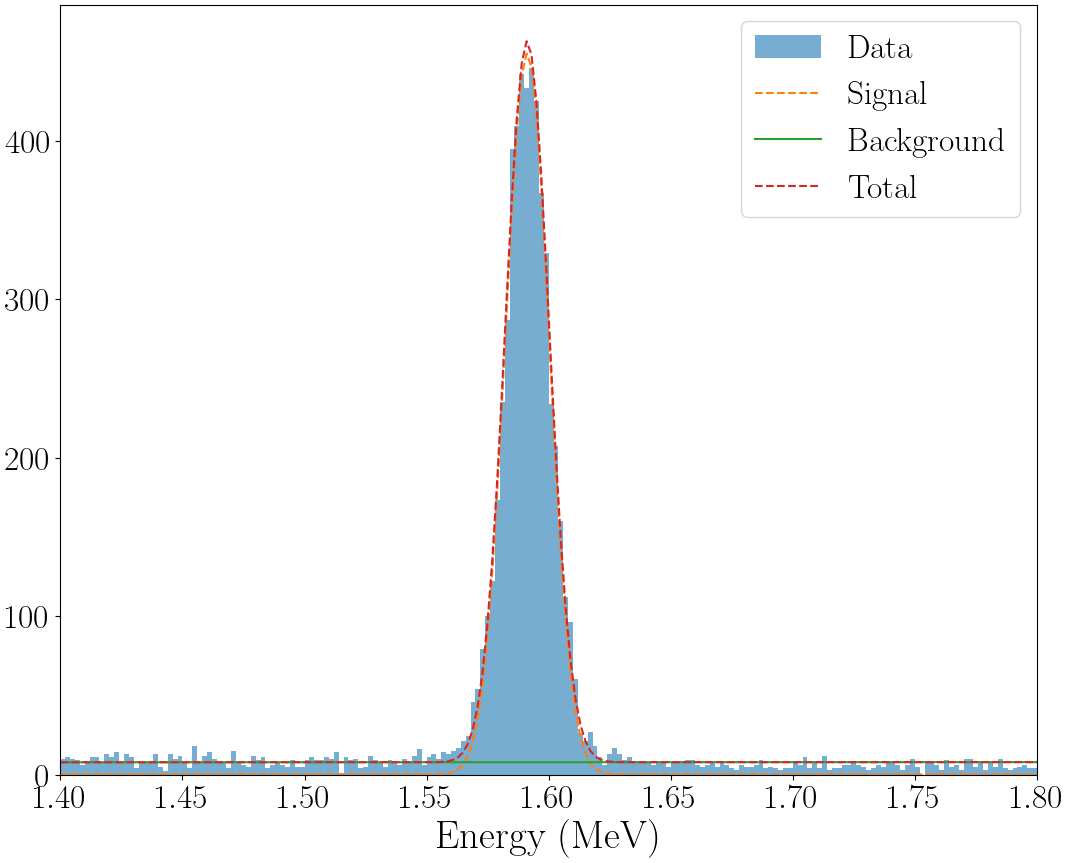

Blob cut: 0.43400000000000005 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [4610.45254568]
Background events: [180.07942843]
Total events by addition: 5961.288641035142
Total events by row counting: 5958
Total events by addition in ROI: [4790.53197411]
Total events by row counting in ROI: 4799
FOM: [1.79589612] +/- [0.07736627]


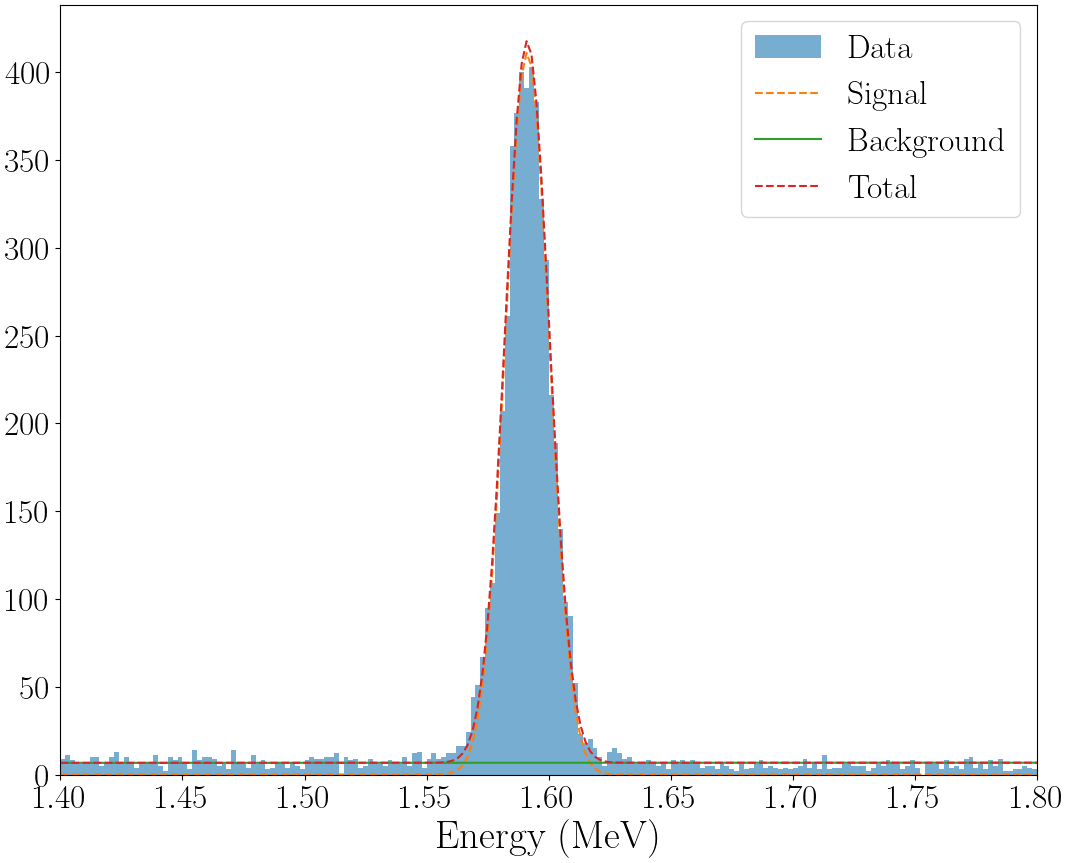

Blob cut: 0.44800000000000006 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [4101.73742344]
Background events: [150.31220122]
Total events by addition: 5229.965546738469
Total events by row counting: 5229
Total events by addition in ROI: [4252.04962466]
Total events by row counting in ROI: 4261
FOM: [1.74880121] +/- [0.0812331]


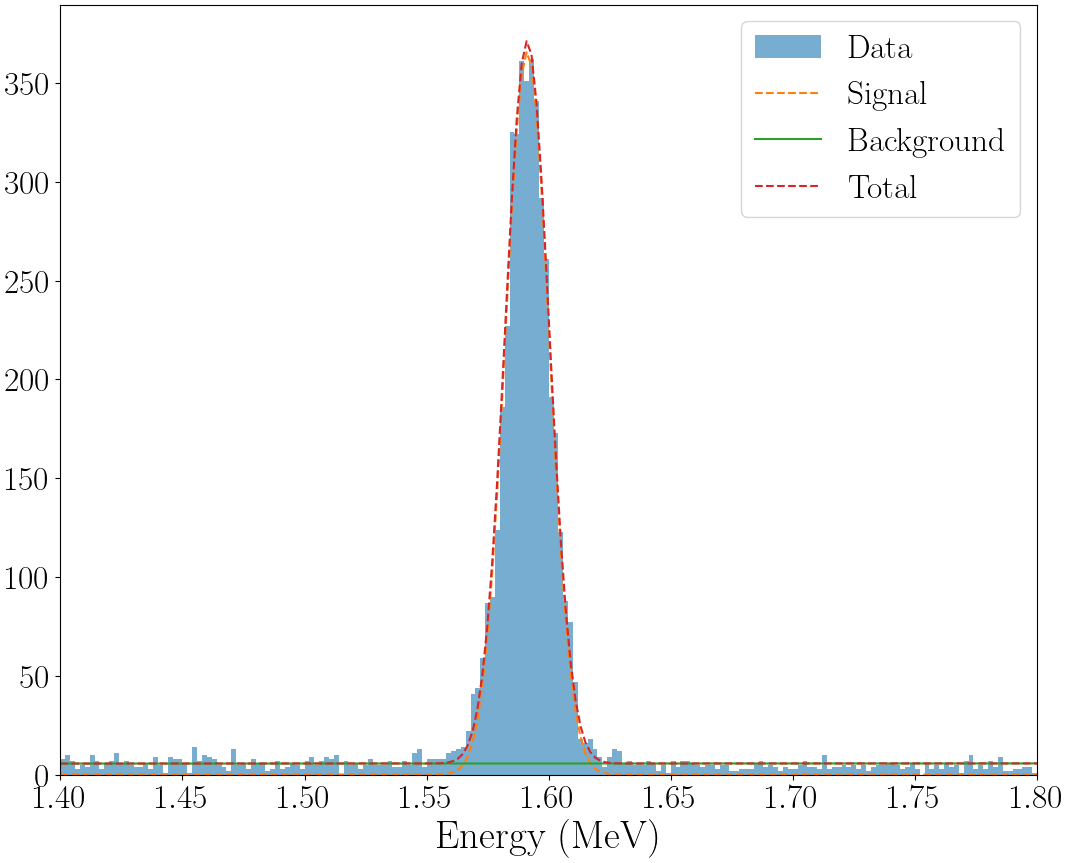

Blob cut: 0.4620000000000001 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [3549.15026029]
Background events: [123.4042158]
Total events by addition: 4475.901606543121
Total events by row counting: 4476
Total events by addition in ROI: [3672.55447609]
Total events by row counting in ROI: 3684
FOM: [1.67004854] +/- [0.08447024]


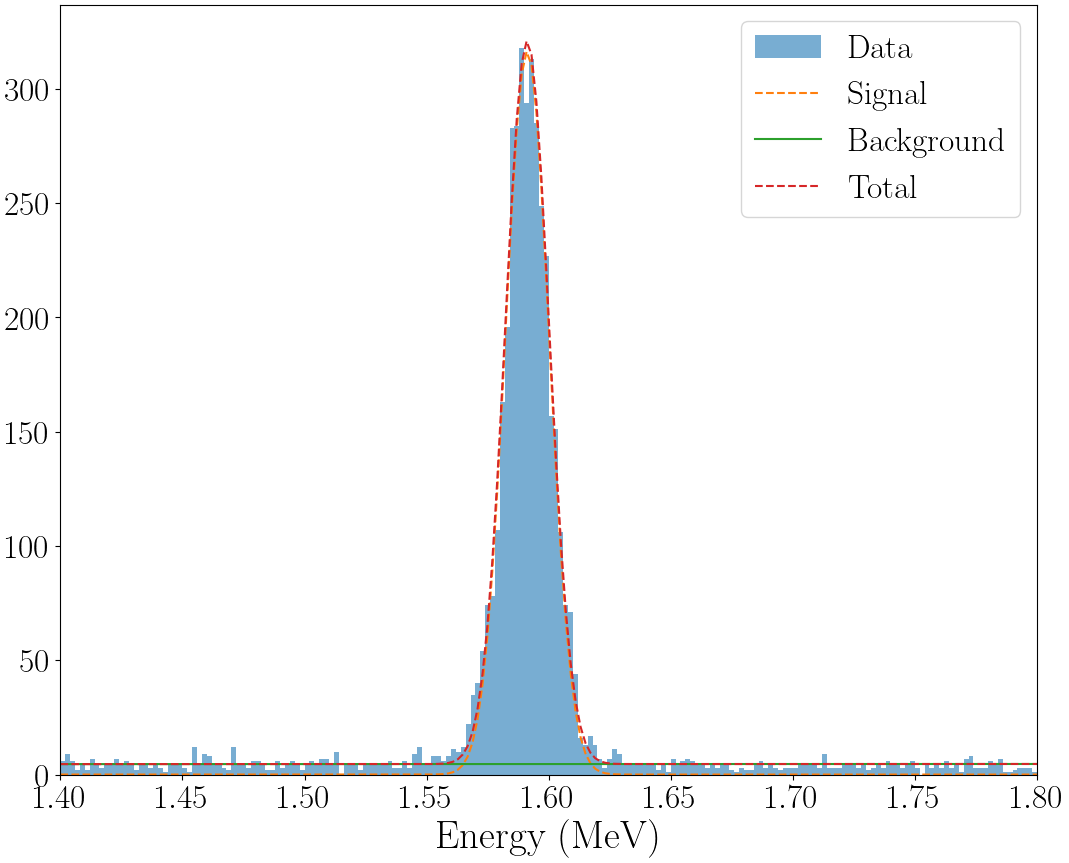

Blob cut: 0.4760000000000001 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [3007.56712274]
Background events: [99.74895716]
Total events by addition: 3757.045833304035
Total events by row counting: 3757
Total events by addition in ROI: [3107.3160799]
Total events by row counting in ROI: 3117
FOM: [1.57409469] +/- [0.08749267]


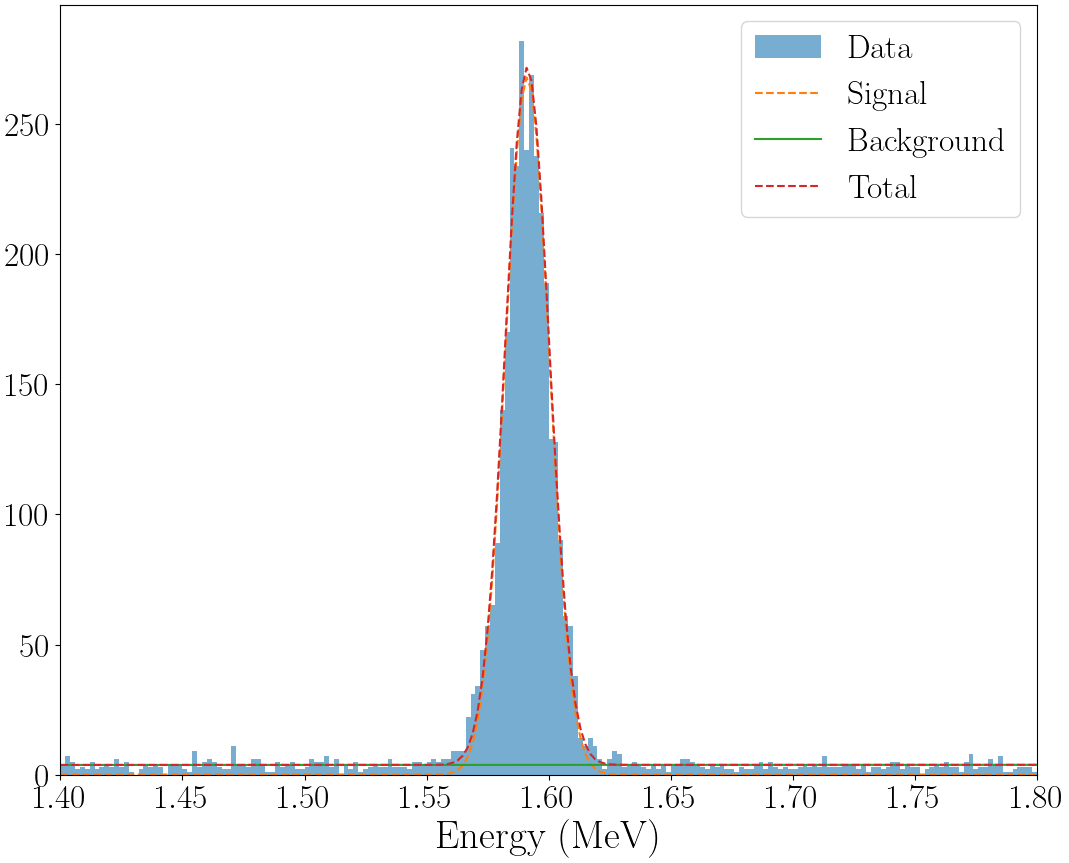

Blob cut: 0.49000000000000005 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [2457.22524066]
Background events: [78.32325159]
Total events by addition: 3045.977702588653
Total events by row counting: 3046
Total events by addition in ROI: [2535.54849225]
Total events by row counting in ROI: 2543
FOM: [1.45134052] +/- [0.09004781]


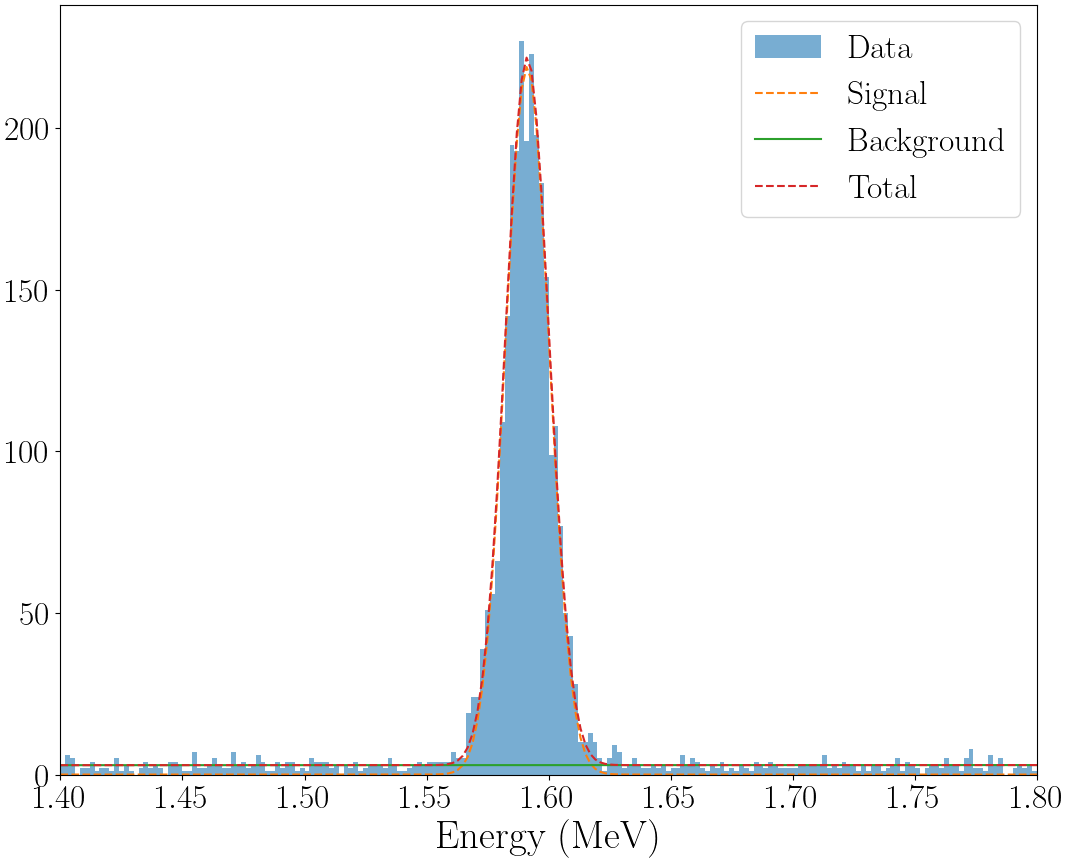

Blob cut: 0.5040000000000001 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [1996.47650228]
Background events: [60.96045862]
Total events by addition: 2454.940928443914
Total events by row counting: 2455
Total events by addition in ROI: [2057.4369609]
Total events by row counting in ROI: 2063
FOM: [1.33662567] +/- [0.09310985]


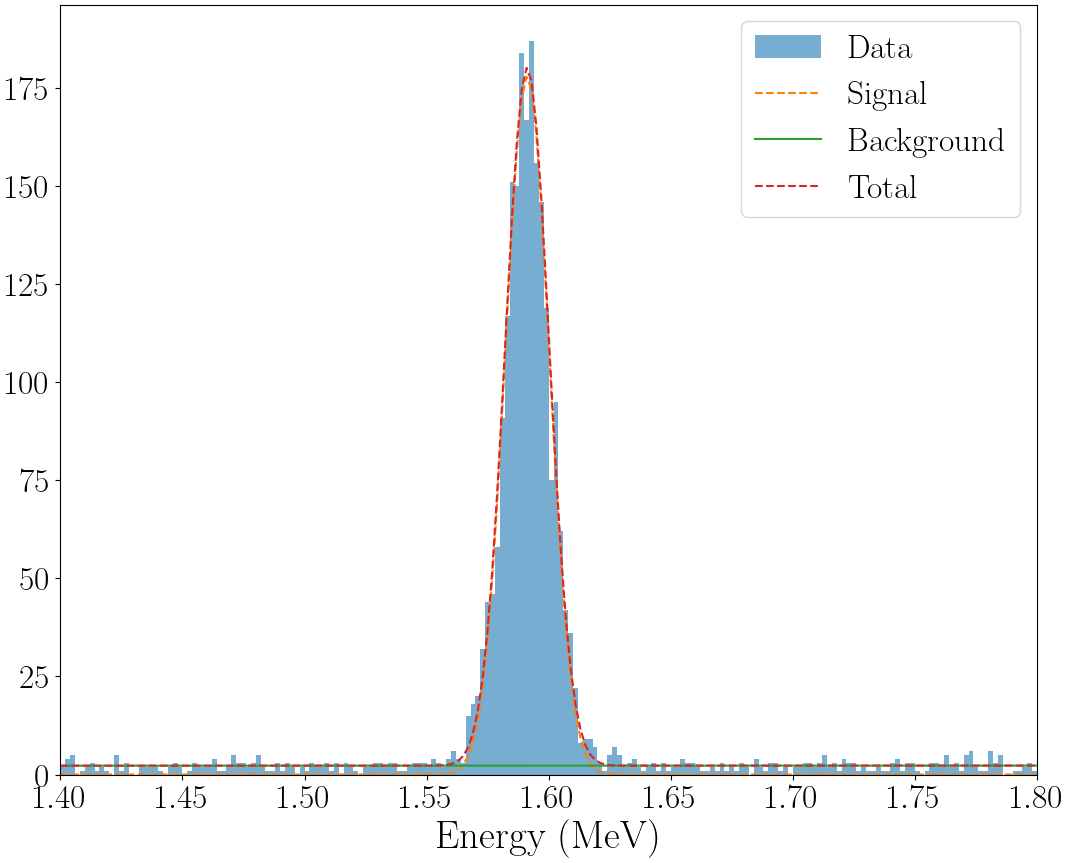

Blob cut: 0.5180000000000001 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [1536.139546]
Background events: [47.20930887]
Total events by addition: 1891.1588799097256
Total events by row counting: 1891
Total events by addition in ROI: [1583.34885487]
Total events by row counting in ROI: 1587
FOM: [1.16865563] +/- [0.09199937]


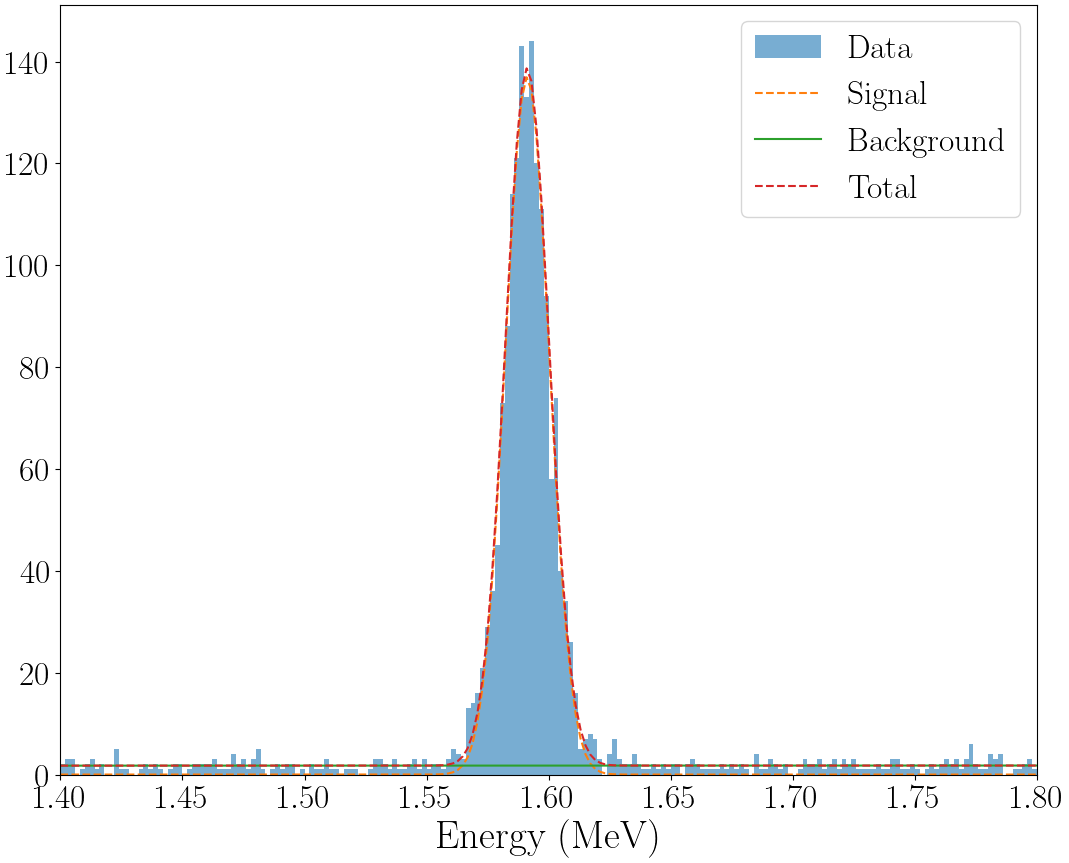

Blob cut: 0.532 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [1168.31830886]
Background events: [36.32131743]
Total events by addition: 1441.42206924441
Total events by row counting: 1442
Total events by addition in ROI: [1204.63962629]
Total events by row counting in ROI: 1208
FOM: [1.01332812] +/- [0.09057594]


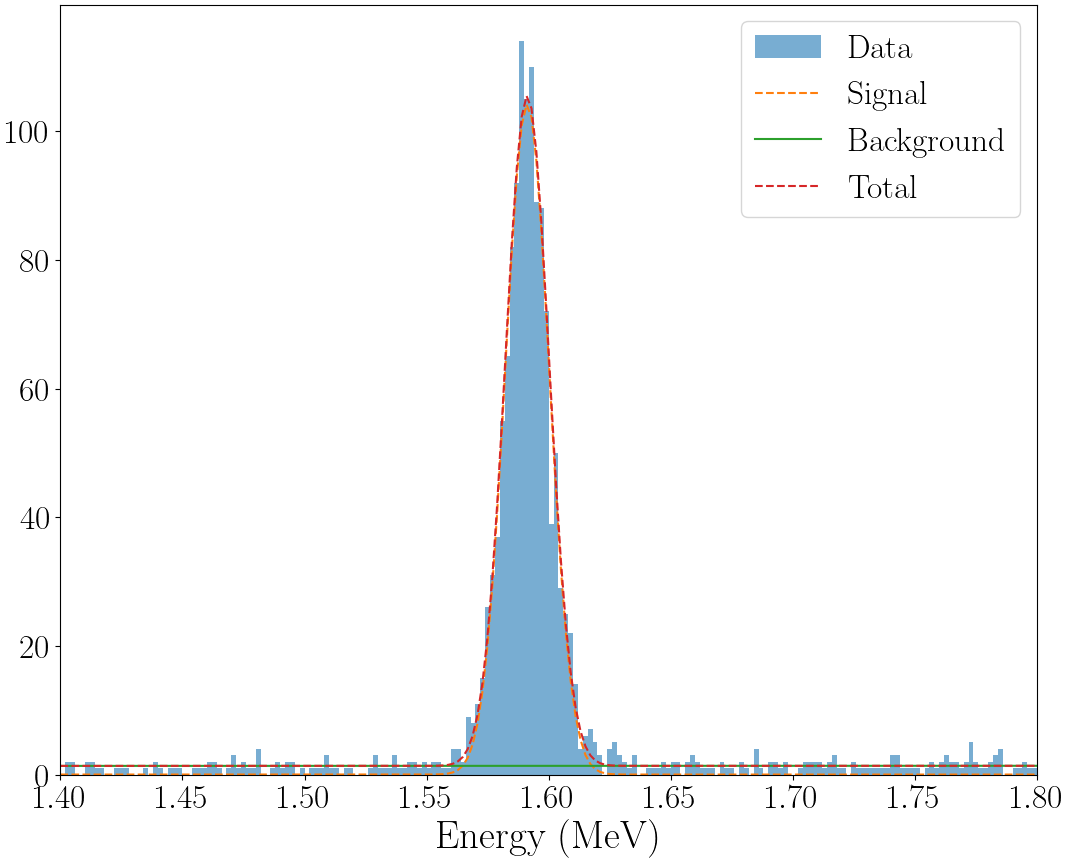

Blob cut: 0.546 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [858.07897021]
Background events: [28.20482212]
Total events by addition: 1070.02087044597
Total events by row counting: 1070
Total events by addition in ROI: [886.28379233]
Total events by row counting in ROI: 887
FOM: [0.84456928] +/- [0.0856303]


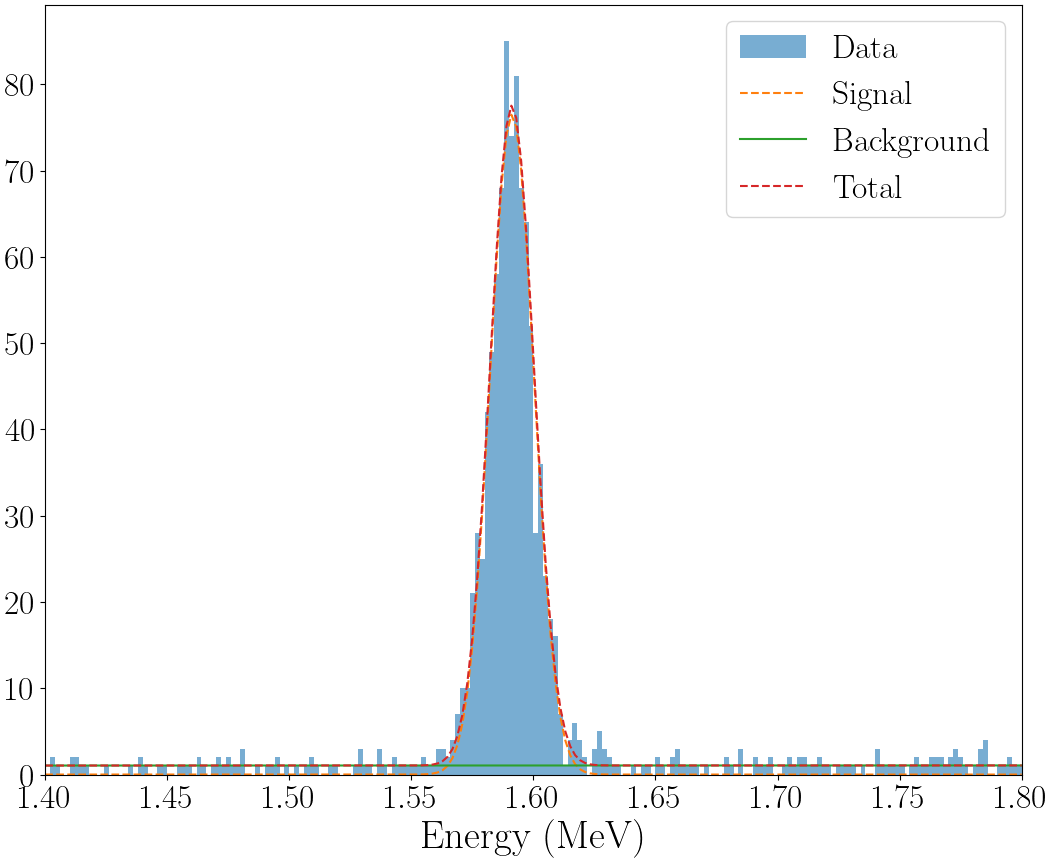

Blob cut: 0.56 MeV
Printing over integral range (np.float64(1.5642962887574587), np.float64(1.6181319137831738))
Signal events: [608.74798707]
Background events: [19.59137617]
Total events by addition: 755.999562131552
Total events by row counting: 756
Total events by addition in ROI: [628.33936324]
Total events by row counting in ROI: 629
FOM: [0.71891041] +/- [0.08702707]


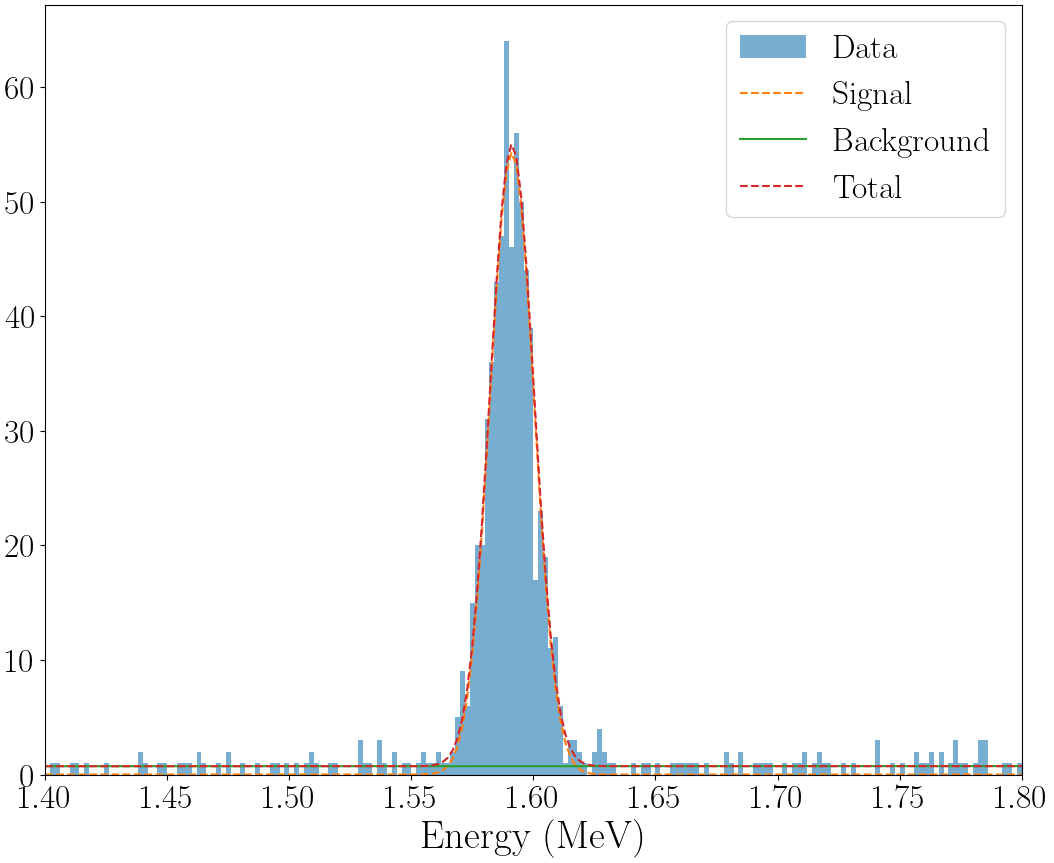

'yerr' (shape: (41, 1)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'y' (shape: (41, 1))


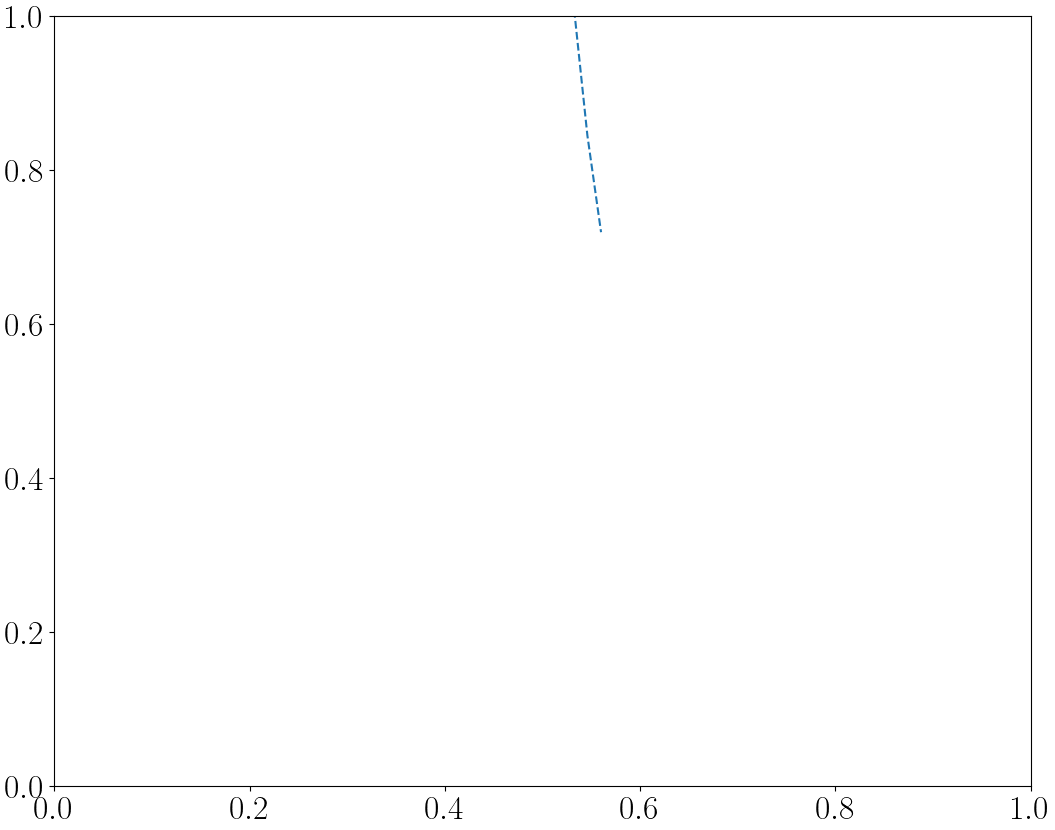

In [84]:
cut_list = np.linspace(0, 0.56, 41)
# only one value
fit_info = dict(bins = 80, fit_range = (1.4, 1.8))

mu_config    = dict(
                value    = 1.59,
                floating = False,
                lower    = 1.4,
                upper    = 1.8)

sigma_config = dict(
                value    = 0.1,
                floating = False,
                lower    = 0)

tau_config   = dict(
                value    = 0.03,
                floating = False,
                lower    = 0,
                upper    = 1)


seeds = dict(
            ns = data.event.nunique()/2,
            nb = data.event.nunique()/2,
            signal = {'mu_config': mu_config,
                      'sigma_config': sigma_config},
            background = {'lambda_config': tau_config})


# mkdir
output_path = Path(f'./output/{timestamp}').mkdir(parents = True, exist_ok=True)

x = FOM.FOM(data, fitf.gaussian_no_N, fitf.exp_no_N, seeds = seeds, fitting_info = fit_info, plot = True, output_path = f'./output/{timestamp}/', cut_list = cut_list)



456015


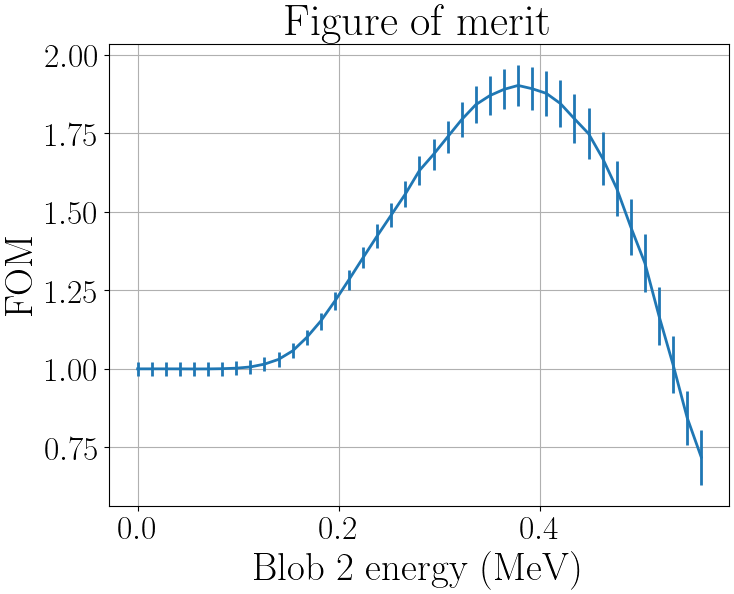

Max FOM as 1.90+/-0.07 at 0.38 MeV
Signal events at peak: 6361.19
Background events at peak: 305.62
Initial signal events: 8357.04
Initial background events: 1908.29
Signal Efficiency at peak: 0.761 +/- 0.013
Background Rejection at peak: 0.160 +/- 0.010


In [92]:
# load in the csv and visualise
import csv
import matplotlib.pyplot as plt

def read_FOM_csv(path):
    data = np.genfromtxt(path, delimiter=',')
    n    = len(data) // 5

    return dict(
        cut_list = data[0*n : 1*n, 0],
        fom      = data[0*n : 1*n, 1],
        fom_err  = data[1*n : 2*n, 1],
        ns_l     = data[2*n : 3*n, 0],
        nb_l     = data[2*n : 3*n, 1],
        e        = data[3*n : 4*n, 0],
        e_err    = data[3*n : 4*n, 1],
        b        = data[4*n : 5*n, 0],
        b_err    = data[4*n : 5*n, 1],
    )

FOM_info = read_FOM_csv(f'output/{timestamp}/FOM.csv')


FOM_clean = FOM_info['fom']
FOM_clean[(FOM_clean > 5) | (FOM_clean < 0)] = 0

print('='*20)
print(f'{timestamp}')
print('='*20)
plt.figure(figsize = (8,6))
plt.errorbar(FOM_info['cut_list'], FOM_clean, yerr = FOM_info['fom_err'], linewidth = 2)
plt.xlabel('Blob 2 energy (MeV)')
plt.title(f'Figure of merit')
plt.ylabel('FOM')
plt.grid()
plt.savefig('/home/e78368jw/Documents/topology_paper/figures/FOM.pdf')
plt.show()
max_fom_index = np.argmax(FOM_clean)
max_fom       = FOM_clean[max_fom_index]
max_fom_error = FOM_info['fom_err'][max_fom_index]
cut_pos       = FOM_info['cut_list'][max_fom_index]
print(f"Max FOM as {max_fom:.2f}+/-{max_fom_error:.2f} at {cut_pos:.2f} MeV")
print(f"Signal events at peak: {FOM_info['ns_l'][max_fom_index]:.2f}")
print(f"Background events at peak: {FOM_info['nb_l'][max_fom_index]:.2f}")
print(f"Initial signal events: {FOM_info['ns_l'][0]:.2f}")
print(f"Initial background events: {FOM_info['nb_l'][0]:.2f}")

print(f'Signal Efficiency at peak: {FOM_info['e'][max_fom_index]:.3f} +/- {FOM_info['e_err'][max_fom_index]:.3f}')

print(f'Background Rejection at peak: {FOM_info['b'][max_fom_index]:.3f} +/- {FOM_info['b_err'][max_fom_index]:.3f}')

In [ ]:
print(np.diff(cut_list))

e, e_err = (FOM_info['e'], FOM_info['e_err'])
b, b_err = (FOM_info['b'], FOM_info['b_err'])

[0.014 0.014 0.014 0.014 0.014 0.014 0.014 0.014 0.014 0.014 0.014 0.014
 0.014 0.014 0.014 0.014 0.014 0.014 0.014 0.014 0.014 0.014 0.014 0.014
 0.014 0.014 0.014 0.014 0.014 0.014 0.014 0.014 0.014 0.014 0.014 0.014
 0.014 0.014 0.014 0.014]
[0.03237372 0.0323718  0.0323718  0.03236232 0.032349   0.03231326
 0.03224534 0.0321235  0.03189813 0.03146417 0.03069672 0.02944292
 0.02773512 0.02574312 0.02365517 0.0217568  0.01997594 0.01854752
 0.01726538 0.01608466 0.01493748 0.01406861 0.01324051 0.01244116
 0.0117376  0.01113854 0.0104935  0.00986745 0.00931536 0.00863454
 0.0079854  0.00735646 0.00667293 0.00600658 0.00536875 0.00473189
 0.00415631 0.00364482 0.00318809 0.00280352 0.00233134]


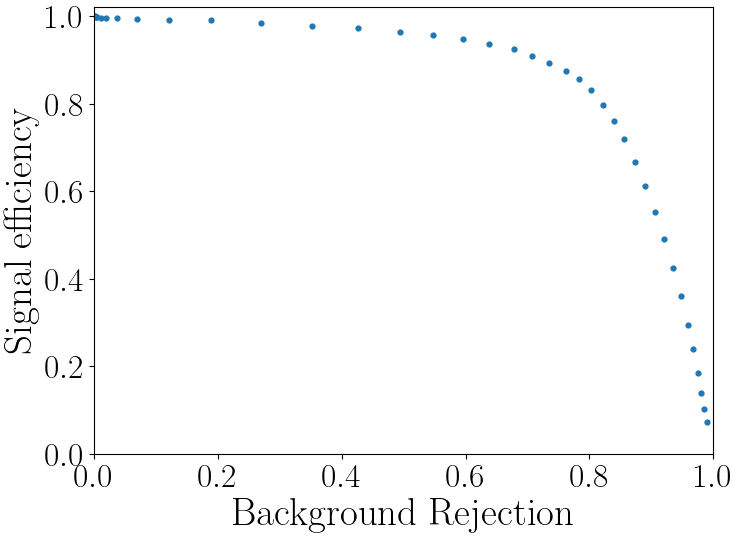

In [ ]:
signal_eff  = FOM_info['ns_l'] / FOM_info['ns_l'].max()
background_rej = 1 - (FOM_info['nb_l'] / FOM_info['nb_l'].max())


# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(background_rej, signal_eff, s = 12)

ax.set_xlabel("Background Rejection")
ax.set_ylabel("Signal efficiency")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

plt.tight_layout()

plt.savefig('/home/e78368jw/Documents/topology_paper/figures/SigEfic_BacRej.pdf')


#print('='*20)
#print(f'{timestamp}')
#print('='*20)
#plt.errorbar(FOM_info['cut_list'], FOM_clean, yerr = FOM_info['fom_err'])
#plt.xlabel('blob energy (MeV)')
#plt.title(f'Figure of merit')
#plt.ylabel('FOM')
#plt.grid()
#plt.savefig('/home/e78368jw/Documents/topology_paper/figures/FOM.pdf')
#plt.show()

  0%|          | 0/5 [00:00<?, ?it/s]

557024
'yerr' (shape: (36, 1)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'y' (shape: (36, 1))
557024






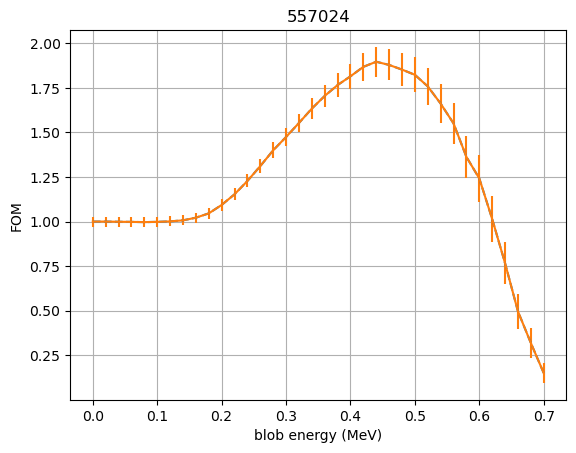

Max FOM as 1.90 at 0.44 MeV
Signal events at peak: 3568.90
Background events at peak: 199.38
Initial signal events: 4933.62
Initial background events: 1370.12
658015
'yerr' (shape: (41, 1)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'y' (shape: (41, 1))
658015






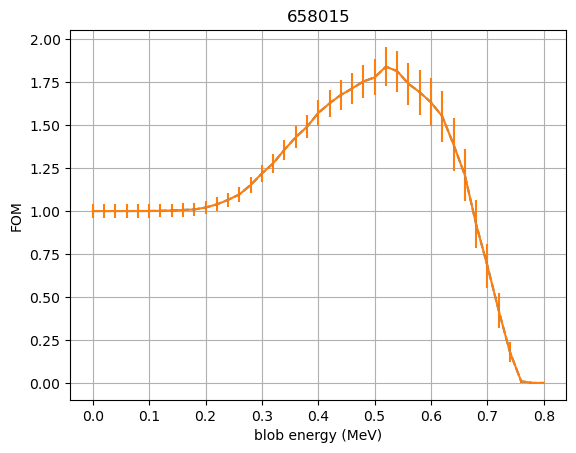

Max FOM as 1.84 at 0.52 MeV
Signal events at peak: 1380.29
Background events at peak: 103.71
Initial signal events: 2161.45
Initial background events: 861.13
658018
'yerr' (shape: (41, 1)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'y' (shape: (41, 1))
658018






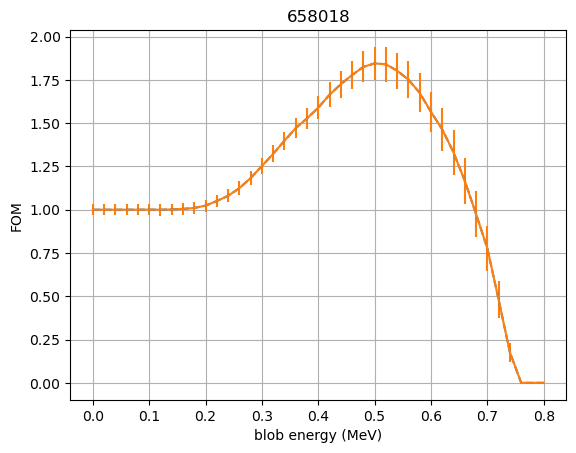

Max FOM as 1.85 at 0.50 MeV
Signal events at peak: 2127.70
Background events at peak: 153.55
Initial signal events: 3066.24
Initial background events: 1085.72
658021
'yerr' (shape: (41, 1)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'y' (shape: (41, 1))
658021






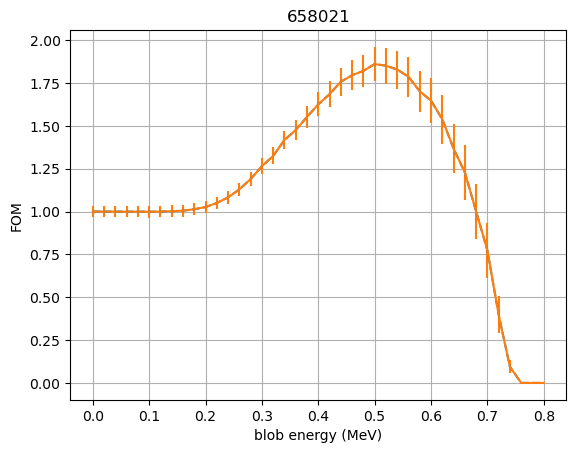

Max FOM as 1.86 at 0.50 MeV
Signal events at peak: 1930.06
Background events at peak: 138.58
Initial signal events: 2883.48
Initial background events: 1070.68
658024
'yerr' (shape: (41, 1)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'y' (shape: (41, 1))
658024






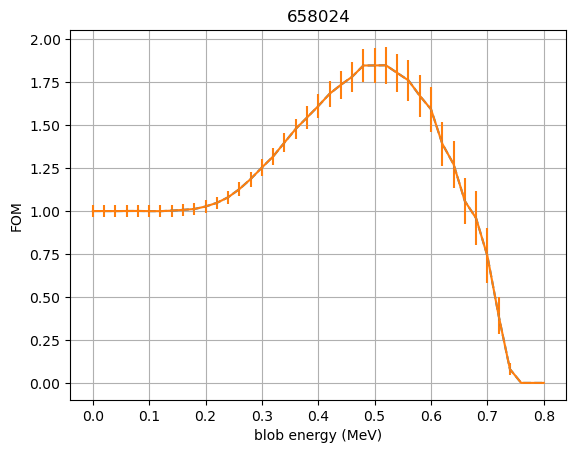

Max FOM as 1.85 at 0.52 MeV
Signal events at peak: 1687.81
Background events at peak: 116.98
Initial signal events: 2717.98
Initial background events: 1036.21


In [3]:
# massive iterator
#ts_list = [355015, 355018, 355021, 355024, 456015, 456018, 456021, 456024, 557015, 557018, 557021, 557024, 658015, 658018, 658021, 658024]
#ts_list = [456015, 456018, 456021, 456024, 557015, 557018, 557021, 557024, 658015, 658018, 658021, 658024]
ts_list = [557024, 658015, 658018, 658021, 658024]
ts_list = [str(x) for x in ts_list]

for timestamp in tqdm(ts_list):
    data = pd.read_hdf(f'/home/e78368jw/Documents/topology_data/p_scan_110526/{timestamp}/full_dataset_15589_15590_15591_15592_{timestamp}.h5', 'Tracking/Tracks') 

    print('='*20)
    print(f'{timestamp}')
    print('='*20)

    if '6580' in timestamp:
        cut_list = np.linspace(0, 0.8, 41)
    elif '5570' in timestamp:
        cut_list = np.linspace(0, 0.7, 36)
    else:
        cut_list = np.linspace(0, 0.6, 31)
    
    fit_info = dict(bins = 80, fit_range = (1.4, 1.8))

    mu_config    = dict(
                    value    = 1.59,
                    floating = False,
                    lower    = 1.4,
                    upper    = 1.8)

    sigma_config = dict(
                    value    = 0.1,
                    floating = False,
                    lower    = 0)

    tau_config   = dict(
                    value    = 0.03,
                    floating = False,
                    lower    = 0,
                    upper    = 1)


    seeds = dict(
                ns = data.event.nunique()/2,
                nb = data.event.nunique()/2,
                signal = {'mu_config': mu_config,
                          'sigma_config': sigma_config},
                background = {'lambda_config': tau_config})


    # mkdir
    output_path = Path(f'./output/{timestamp}').mkdir(parents = True, exist_ok=True)

    x = FOM.FOM(data, fitf.gaussian_no_N, fitf.exp_no_N, seeds = seeds, fitting_info = fit_info, plot = False, output_path = f'./output/{timestamp}/', cut_list = cut_list, verbose = False)


    FOM_info = read_FOM_csv(f'output/{timestamp}/FOM.csv')


    FOM_clean = FOM_info['fom']
    FOM_clean[(FOM_clean > 5) | (FOM_clean < 0)] = 0

    print('='*20)
    print(f'{timestamp}')
    print('='*20)
    print('\n\n\n')
    plt.errorbar(FOM_info['cut_list'], FOM_clean, yerr = [x if x >= 0 else 0 for x in FOM_info['fom_err']])
    plt.xlabel('blob energy (MeV)')
    plt.title(f'{timestamp}')
    plt.ylabel('FOM')
    plt.grid()
    plt.show()
    max_fom_index = np.argmax(FOM_clean)
    max_fom       = FOM_clean[max_fom_index]
    cut_pos       = FOM_info['cut_list'][max_fom_index]
    print(f"Max FOM as {max_fom:.2f} at {cut_pos:.2f} MeV")
    print(f"Signal events at peak: {FOM_info['ns_l'][max_fom_index]:.2f}")
    print(f"Background events at peak: {FOM_info['nb_l'][max_fom_index]:.2f}")
    print(f"Initial signal events: {FOM_info['ns_l'][0]:.2f}")
    print(f"Initial background events: {FOM_info['nb_l'][0]:.2f}")

355015






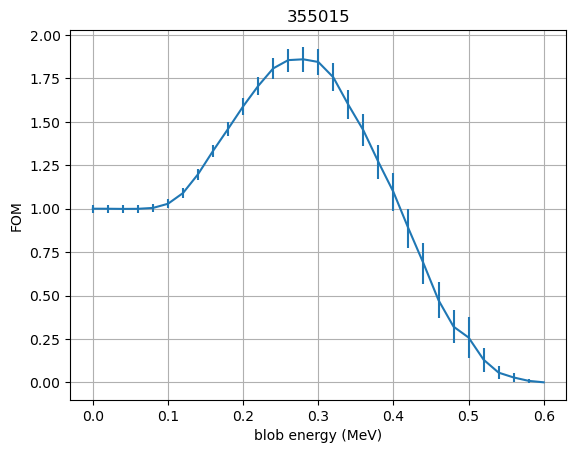

Max FOM as 1.86 at 0.28 MeV
Signal events at peak: 5783.95
Background events at peak: 248.43
Initial signal events: 7787.45
Initial background events: 1558.79
355018






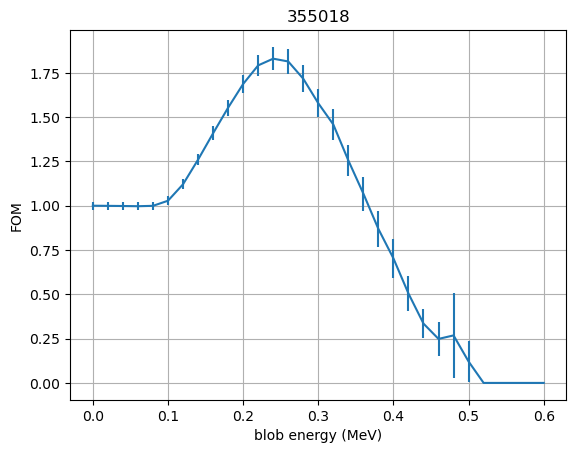

Max FOM as 1.83 at 0.24 MeV
Signal events at peak: 6233.80
Background events at peak: 285.42
Initial signal events: 8143.98
Initial background events: 1630.99
355021






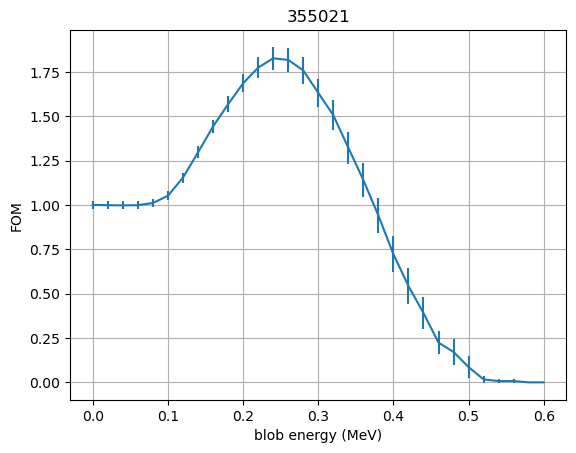

Max FOM as 1.83 at 0.24 MeV
Signal events at peak: 6468.89
Background events at peak: 306.66
Initial signal events: 8386.45
Initial background events: 1719.49
355024






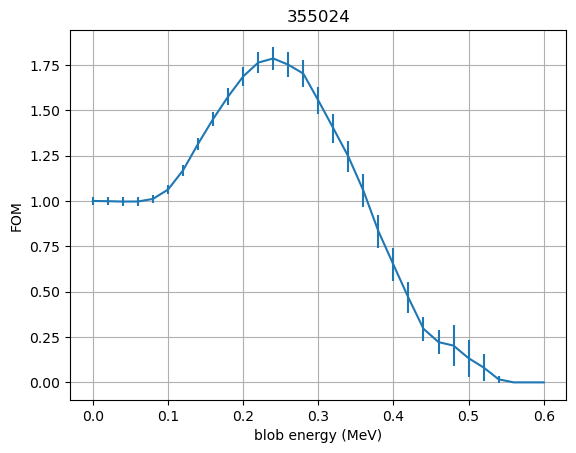

Max FOM as 1.79 at 0.24 MeV
Signal events at peak: 6255.32
Background events at peak: 294.62
Initial signal events: 8510.25
Initial background events: 1738.37
456015






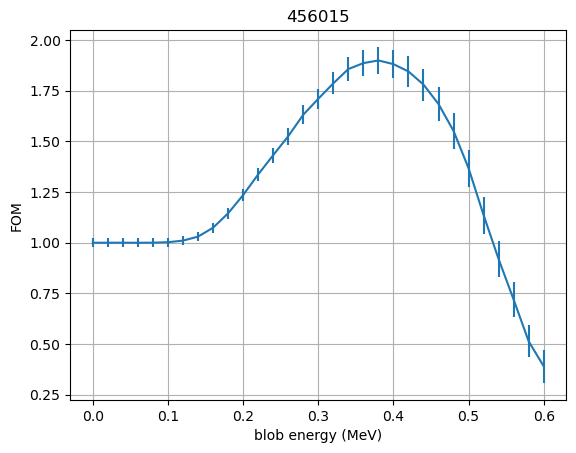

Max FOM as 1.90 at 0.38 MeV
Signal events at peak: 6315.30
Background events at peak: 302.20
Initial signal events: 8357.04
Initial background events: 1908.29
456018






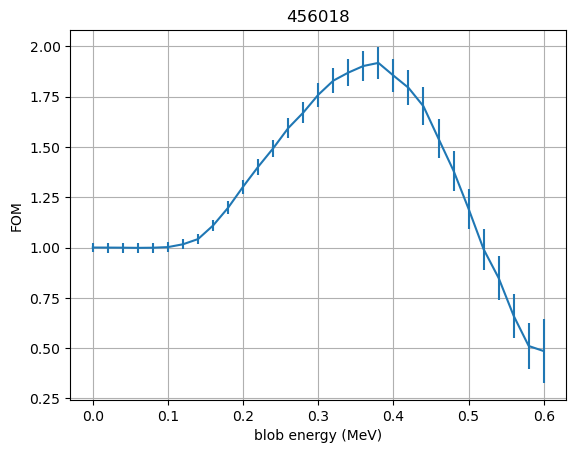

Max FOM as 1.92 at 0.38 MeV
Signal events at peak: 4883.29
Background events at peak: 206.82
Initial signal events: 7048.66
Initial background events: 1584.03
456021






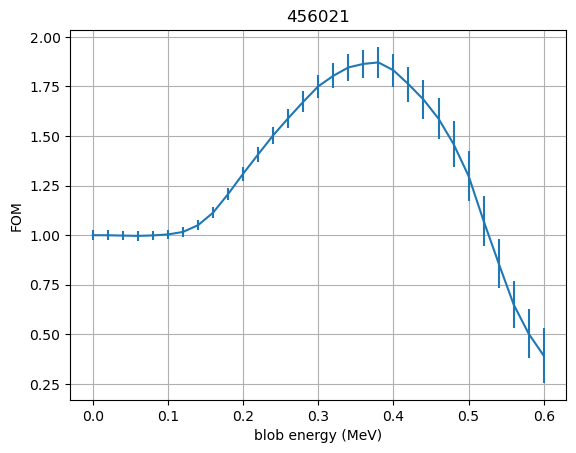

Max FOM as 1.87 at 0.38 MeV
Signal events at peak: 4746.83
Background events at peak: 201.75
Initial signal events: 7168.21
Initial background events: 1610.46
456024






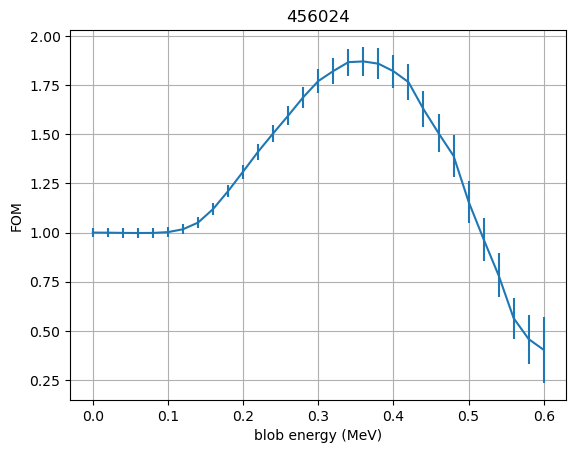

Max FOM as 1.87 at 0.36 MeV
Signal events at peak: 4976.49
Background events at peak: 237.70
Initial signal events: 6888.29
Initial background events: 1593.96
557015






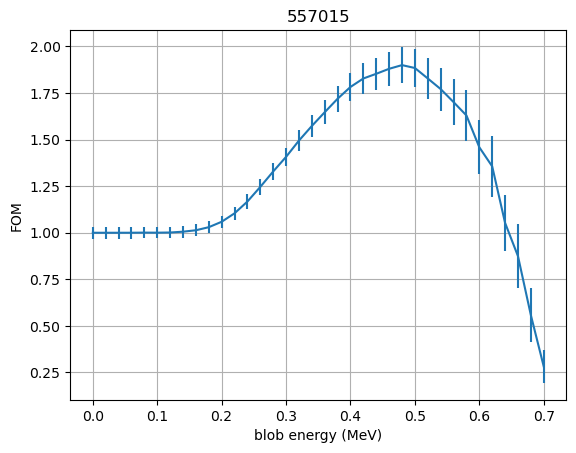

Max FOM as 1.90 at 0.48 MeV
Signal events at peak: 2609.88
Background events at peak: 140.77
Initial signal events: 3867.35
Initial background events: 1115.59
557018






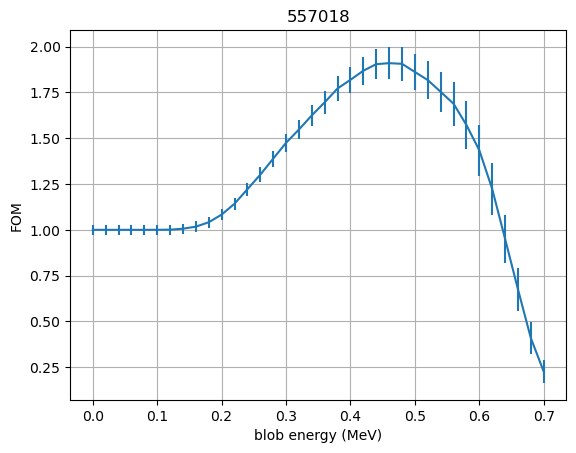

Max FOM as 1.91 at 0.46 MeV
Signal events at peak: 3415.90
Background events at peak: 181.43
Initial signal events: 4883.66
Initial background events: 1351.71
557021






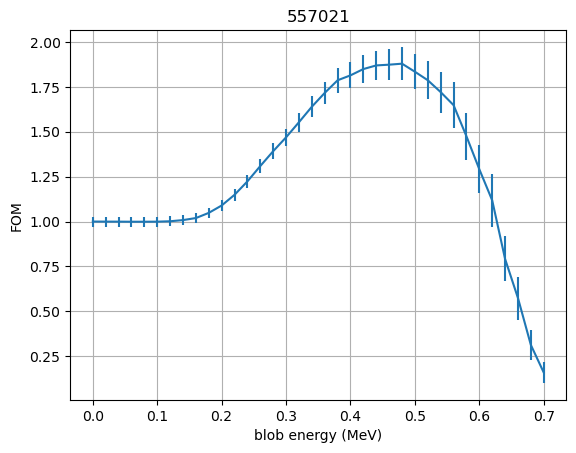

Max FOM as 1.88 at 0.48 MeV
Signal events at peak: 2922.76
Background events at peak: 144.11
Initial signal events: 4806.62
Initial background events: 1376.39
557024






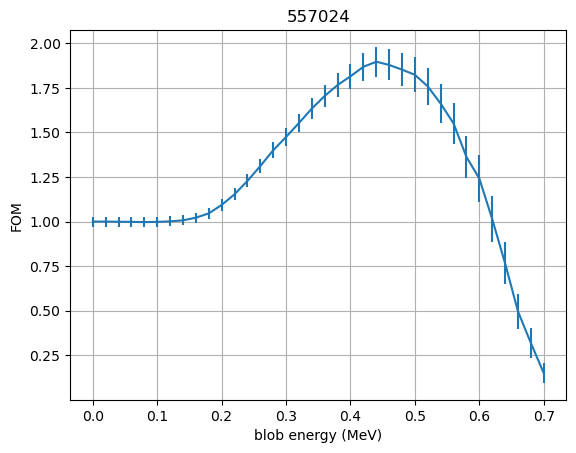

Max FOM as 1.90 at 0.44 MeV
Signal events at peak: 3568.90
Background events at peak: 199.38
Initial signal events: 4933.62
Initial background events: 1370.12
658015






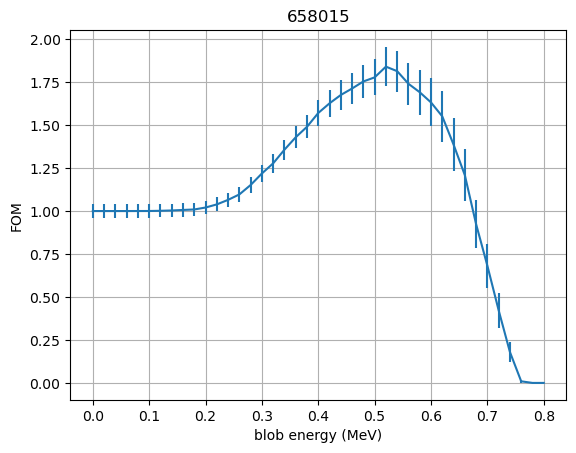

Max FOM as 1.84 at 0.52 MeV
Signal events at peak: 1380.29
Background events at peak: 103.71
Initial signal events: 2161.45
Initial background events: 861.13
658018






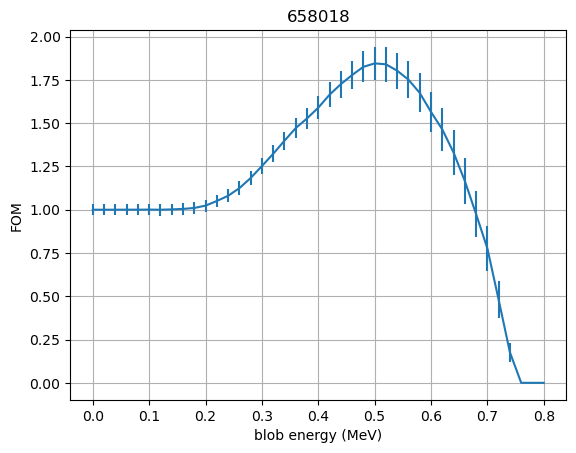

Max FOM as 1.85 at 0.50 MeV
Signal events at peak: 2127.70
Background events at peak: 153.55
Initial signal events: 3066.24
Initial background events: 1085.72
658021






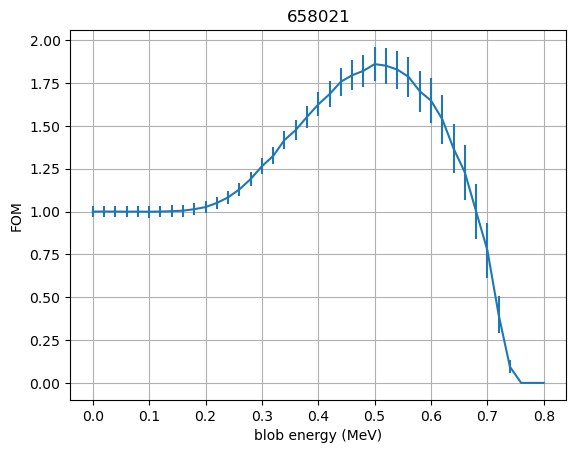

Max FOM as 1.86 at 0.50 MeV
Signal events at peak: 1930.06
Background events at peak: 138.58
Initial signal events: 2883.48
Initial background events: 1070.68
658024






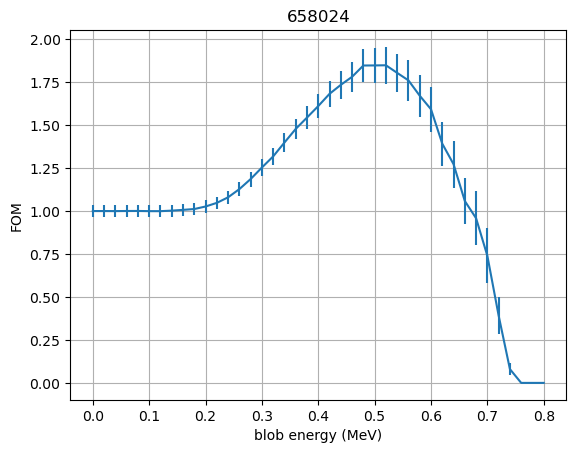

Max FOM as 1.85 at 0.52 MeV
Signal events at peak: 1687.81
Background events at peak: 116.98
Initial signal events: 2717.98
Initial background events: 1036.21


In [6]:

ts_list = [355015, 355018, 355021, 355024, 456015, 456018, 456021, 456024, 557015, 557018, 557021, 557024, 658015, 658018, 658021, 658024]
for timestamp in ts_list:

    FOM_info = read_FOM_csv(f'output/{timestamp}/FOM.csv')


    FOM_clean = FOM_info['fom']
    FOM_clean[(FOM_clean > 5) | (FOM_clean < 0)] = 0
    FOM_err = FOM_info['fom_err']
    FOM_err[(FOM_err > 5) | (FOM_err < 0)] = 0
    print('='*20)
    print(f'{timestamp}')
    print('='*20)
    print('\n\n\n')
    plt.errorbar(FOM_info['cut_list'], FOM_clean, yerr = FOM_err)
    plt.xlabel('blob energy (MeV)')
    plt.title(f'{timestamp}')
    plt.ylabel('FOM')
    plt.grid()
    plt.show()
    max_fom_index = np.argmax(FOM_clean)
    max_fom       = FOM_clean[max_fom_index]
    cut_pos       = FOM_info['cut_list'][max_fom_index]
    print(f"Max FOM as {max_fom:.2f} at {cut_pos:.2f} MeV")
    print(f"Signal events at peak: {FOM_info['ns_l'][max_fom_index]:.2f}")
    print(f"Background events at peak: {FOM_info['nb_l'][max_fom_index]:.2f}")
    print(f"Initial signal events: {FOM_info['ns_l'][0]:.2f}")
    print(f"Initial background events: {FOM_info['nb_l'][0]:.2f}")